# `geoai-datacubes` — the grand tour

**Welcome!** This notebook is the one-stop-shop for everyone joining the
[BuckAI Observatory](https://buckai-observatory.org) `geoai-datacubes`
pipeline with no prior geospatial-ML background. Run it top to bottom on a
fresh checkout and you will have built — from scratch, with no credentials —
a multi-mission, multi-resolution, AI-ready satellite data cube over central
Columbus, OH.

> "The entire repository is intended to remove all such barriers and quickly
> get to the funner part of ML/DL."
> — *Joachim Moortgat, Director, BuckAI Observatory*

#### What this notebook covers
1. Setup and environment
2. The four ways to define an Area of Interest (AOI)
3. Fetching one mission at a time — Sentinel-2 (L2A and L1C), Sentinel-1
   RTC, Landsat, Copernicus DEM, ESA WorldCover
4. The commercial path — PlanetScope (4-band and 8-band SuperDove)
5. Cloud masking up close (SCL, BQA, UDM2)
6. NaN handling — `drop`, `interpolate`, `mask`
7. Tiling — with and without overlap, visualised
8. Train / val / test splits — `random`, `block`, `stripes`, `regions`
9. Multi-mission fusion onto a common UTM grid
10. Reading metadata back out from tiles (GeoTIFF tags + sidecars)
11. Augmentation
12. Exporting for training (Zarr / LMDB)
13. Doing the same from plain Python (`python main.py`)
14. Running on an HPC cluster (SLURM)
15. Where to go next

#### How to read this notebook
Each section opens with a short markdown explanation of *why* a novice
would care, then the code, then commentary on the numbers and the figure.
We deliberately print shapes, CRS, pixel sizes, NaN fractions, and split
counts everywhere — sanity checks make the difference between a model
that works and a model that *looks like* it works.

#### A note on running things from plain Python
Every cell here has an exact equivalent at the bottom of
`modules/sentinel_pipeline/main.py`. The notebook is great for exploration;
for production runs (HPC, Airflow, cron) you want plain Python. See
section 13 for the equivalence and `slurm_examples/` for SLURM templates.
The cluster-specific bits (partition names, modules, JupyterHub URLs)
live in the **BuckAI HPC Handbook**.

## 1. Setup and environment

This notebook lives at `notebooks/00_geoai_datacubes_tour.ipynb` in the
repo. We assume you already created the conda env and installed the
requirements as documented in the [top-level README](../README.md):

```bash
conda create -n geoai python=3.11 -y
conda activate geoai
pip install -r requirements.txt
```

#### No credentials needed
The default provider (`"auto"`) routes each mission to a free, public
endpoint — Earth Search (Element 84) for Sentinel-2 and DEM, Planetary
Computer (Microsoft) for Sentinel-1 RTC, Landsat, and ESA WorldCover.
Nothing in this notebook requires an API key.

#### Optional credentials
If you want to try the commercial PlanetScope path (Section 4) or the
advanced Sentinel Hub provider, copy `.env.example` to `.env` at the
repo root and fill in `PL_API_KEY` or `SH_CLIENT_ID` / `SH_CLIENT_SECRET`.
Sections that need credentials guard against their absence and simply
skip, so the notebook still runs end-to-end without them.

The next cell adds `modules/sentinel_pipeline/` to `sys.path` so we can
`import` the pipeline directly. We also create a `notebooks/_outputs/`
scratch folder where every download, tile, and figure from this notebook
will land — this keeps the rest of the repo clean and makes it easy to
`rm -rf` the outputs if you want to start over.

In [1]:
# --- imports + path setup ---
import os, sys, json, glob, shutil, time, math, warnings
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, Normalize

# locate the repo root from this notebook's CWD (notebooks/)
NB_DIR  = Path.cwd()
if NB_DIR.name != "notebooks":
    # safety net: try to find notebooks/ in parents
    for p in (NB_DIR, *NB_DIR.parents):
        if (p / "notebooks").is_dir() and (p / "modules" / "sentinel_pipeline").is_dir():
            NB_DIR = p / "notebooks"
            break
REPO_ROOT = NB_DIR.parent
PIPE_DIR  = REPO_ROOT / "modules" / "sentinel_pipeline"
sys.path.insert(0, str(PIPE_DIR))

# scratch output folder for this notebook
OUT  = NB_DIR / "_outputs"
DATA = OUT / "data"
FUSE = OUT / "fused"
TILES = OUT / "tiles"
for d in (OUT, DATA, FUSE, TILES):
    d.mkdir(parents=True, exist_ok=True)

# nicer matplotlib defaults
plt.rcParams["figure.dpi"]   = 110
plt.rcParams["savefig.dpi"]  = 110
plt.rcParams["image.cmap"]   = "viridis"
plt.rcParams["axes.grid"]    = False
warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")

print("Repo root :", REPO_ROOT)
print("Pipeline  :", PIPE_DIR)
print("Outputs   :", OUT)

Repo root : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes
Pipeline  : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/modules/sentinel_pipeline
Outputs   : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs


In [2]:
# --- pipeline imports (these must work end-to-end on a fresh checkout) ---
from aoi          import resolve_aoi
from missions     import get_profile, MISSION_PROFILES
from fetch_data   import fetch_sentinel_data
from preprocess   import normalize_band, compute_ndvi, cloud_mask
from tiler        import tile_geotiff
from fusion       import fuse_response_tiffs

print("Available missions:", sorted(MISSION_PROFILES.keys()))

Available missions: ['Copernicus-DEM', 'ESA-WorldCover', 'Landsat', 'Landsat-8', 'Landsat-9', 'PlanetScope-4b', 'PlanetScope-8b', 'Sentinel-1', 'Sentinel-2', 'Sentinel-2-L1C']


## 2. Defining your Area of Interest (AOI)

The pipeline accepts **four** AOI formats, all resolved by
`aoi.py::resolve_aoi(spec)` to the same WGS84 bbox
`[lon_min, lat_min, lon_max, lat_max]`. Pick whichever is most natural
for your workflow:

| Format | When to use |
|---|---|
| `{"bbox": [lon_min, lat_min, lon_max, lat_max]}` | You already know the corners. |
| `{"shapefile": "path/to/aoi.shp"}` | You have a vector polygon (county, watershed, field boundary). Requires `geopandas`. Uses the polygon's **bounding box**. |
| `{"center": (lat, lon), "side_miles": N}` | You know roughly where, want a square AOI of size *N* miles. |
| `{"tile_around": (lat, lon)}` | You want the full Sentinel-2 MGRS tile (~100×100 km) containing the point — fastest first look. |

For the rest of this notebook we use a **tiny ~2 km AOI** over central
Columbus, OH so cells stay fast and the figures stay readable. For "real"
runs you'd want something bigger — the README defaults to a ~5-mile square
around OSU.

In [3]:
# --- demonstrate all four AOI formats ---
specs = {
    "bbox            (tiny ~2 km box, central Columbus)" :
        {"bbox": [-83.020, 39.995, -83.000, 40.015]},

    "center+side_miles (5 mi square around OSU campus)" :
        {"center": (40.0067, -83.0305), "side_miles": 5},

    "tile_around     (native S2 MGRS tile containing OSU)" :
        {"tile_around": (40.0067, -83.0305)},

    # shapefile demo: write a 1-feature GeoJSON to disk and resolve it.
    # If geopandas is missing this AOI is skipped (caught below).
}

# --- write a 1-feature GeoJSON so we can also demonstrate the shapefile format ---
gj_path = OUT / "demo_aoi.geojson"
demo_box = [-83.080, 39.990, -83.010, 40.025]
with open(gj_path, "w") as f:
    json.dump({
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature",
            "properties": {"name": "demo_box"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [demo_box[0], demo_box[1]],
                    [demo_box[2], demo_box[1]],
                    [demo_box[2], demo_box[3]],
                    [demo_box[0], demo_box[3]],
                    [demo_box[0], demo_box[1]],
                ]],
            },
        }],
    }, f)
specs["shapefile       (1-feature GeoJSON, bbox of polygon used)"] = {"shapefile": str(gj_path)}

# --- resolve each spec to a WGS84 bbox ---
resolved = {}
for label, spec in specs.items():
    try:
        resolved[label] = resolve_aoi(spec)
    except Exception as e:
        resolved[label] = f"(skipped: {type(e).__name__}: {e})"

print(f"{'Format':52s}  bbox  [lon_min, lat_min, lon_max, lat_max]")
print("-" * 100)
for label, bbox in resolved.items():
    if isinstance(bbox, list):
        side_km = 111 * (bbox[3] - bbox[1])
        print(f"{label:52s}  [{bbox[0]:8.4f}, {bbox[1]:7.4f}, "
              f"{bbox[2]:8.4f}, {bbox[3]:7.4f}]  ({side_km:.1f} km tall)")
    else:
        print(f"{label:52s}  {bbox}")

Format                                                bbox  [lon_min, lat_min, lon_max, lat_max]
----------------------------------------------------------------------------------------------------
bbox            (tiny ~2 km box, central Columbus)    [-83.0200, 39.9950, -83.0000, 40.0150]  (2.2 km tall)
center+side_miles (5 mi square around OSU campus)     [-83.0777, 39.9705, -82.9833, 40.0429]  (8.0 km tall)
tile_around     (native S2 MGRS tile containing OSU)  [-83.3647, 39.6382, -82.0515, 40.6459]  (111.9 km tall)
shapefile       (1-feature GeoJSON, bbox of polygon used)  [-83.0800, 39.9900, -83.0100, 40.0250]  (3.9 km tall)


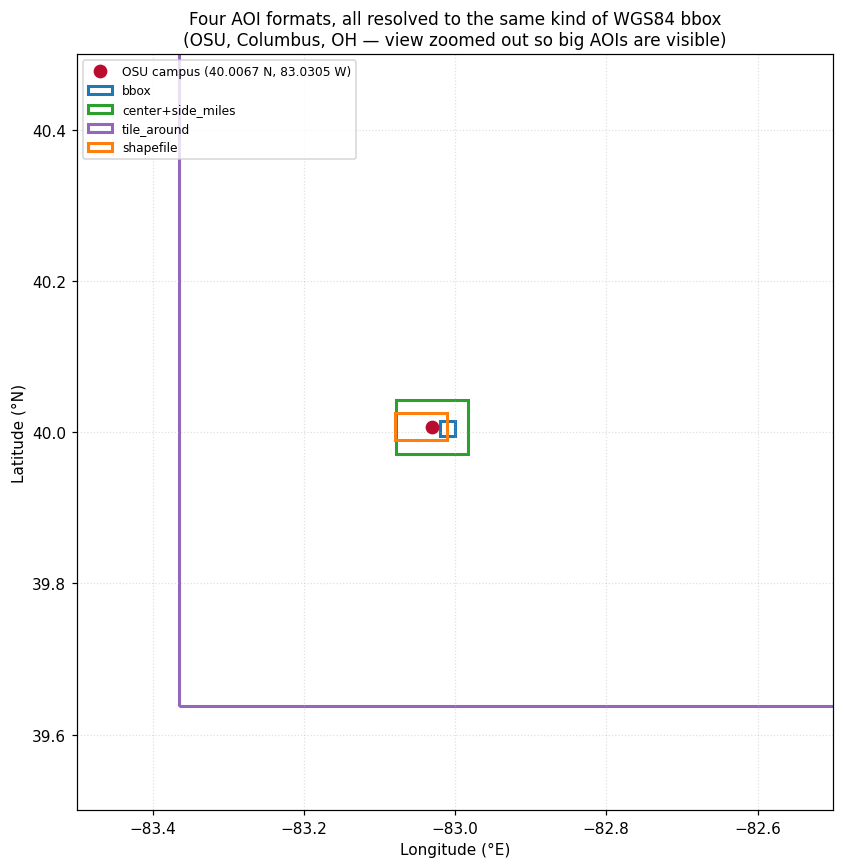

In [4]:
# --- plot all four AOIs over a simple lon/lat 'basemap' ---
fig, ax = plt.subplots(figsize=(8, 8))

# State-scale frame just so the smaller AOIs are visible relative to OSU.
frame = (-83.5, -82.5, 39.5, 40.5)   # (lon_min, lon_max, lat_min, lat_max)

# OSU campus marker
ax.plot(-83.0305, 40.0067, "o", color="#BA0C2F", ms=8,
        label="OSU campus (40.0067 N, 83.0305 W)")

# Each AOI as a coloured rectangle
colors = ["#1f77b4", "#2ca02c", "#9467bd", "#ff7f0e"]
for (label, bbox), c in zip(resolved.items(), colors):
    if not isinstance(bbox, list):
        continue
    rect = Rectangle(
        (bbox[0], bbox[1]),
        bbox[2] - bbox[0],
        bbox[3] - bbox[1],
        fill=False, edgecolor=c, lw=2.0,
        label=label.split()[0],
    )
    ax.add_patch(rect)

ax.set_xlim(frame[0], frame[1])
ax.set_ylim(frame[2], frame[3])
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect("equal")
ax.set_title("Four AOI formats, all resolved to the same kind of WGS84 bbox\n"
             "(OSU, Columbus, OH — view zoomed out so big AOIs are visible)",
             fontsize=11)
ax.grid(True, ls=":", alpha=0.4)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The figure makes the trade-offs concrete:

- **`tile_around`** returns the entire Sentinel-2 MGRS tile (~100 × 100 km).
  Largest area, biggest download, but you only need one point to specify it.
- **`center` + `side_miles`** gives you a clean square of any size — a great
  default when you know the rough location.
- **`shapefile`** lets you reuse polygons you already have (counties,
  ecoregions, study sites). Note that the pipeline uses the polygon's
  **bounding box**, not the polygon itself; if you need to mask outside the
  polygon, do that downstream after tiling.
- **`bbox`** is the most explicit format and the one we use below.

From now on we'll use the tiny ~2 km Columbus box so every cell runs in
seconds.

In [5]:
# --- the tiny working AOI we'll use for the rest of this notebook ---
AOI = {"bbox": [-83.020, 39.995, -83.000, 40.015]}   # ~2 km square, central Columbus
ROI = resolve_aoi(AOI)

# Date window. We pick a wide-ish window so cloud-filtering can find a clear scene.
# (Cloud filtering is applied scene-level; the tiler does the per-pixel masking.)
TIME_RANGE_OPTICAL = ("2024-06-01", "2024-06-30")
TIME_RANGE_RADAR   = ("2024-06-01", "2024-06-30")
TIME_RANGE_LANDSAT = ("2024-05-01", "2024-09-30")   # Landsat revisit is 16d so wider
MAX_CLOUD          = 0.20

# Output resolutions (metres per pixel). Stay at the mission's native ground sampling
# whenever possible — over-resampling either way costs information.
RES_S2  = 10
RES_S1  = 10
RES_LSC = 30
RES_DEM = 30
RES_LULC= 10

print("Working AOI :", ROI, " (~",
      f"{(ROI[3]-ROI[1])*111:.2f} km tall x {(ROI[2]-ROI[0])*111*math.cos(math.radians(ROI[1])):.2f} km wide)")

Working AOI : [-83.02, 39.995, -83.0, 40.015]  (~ 2.22 km tall x 1.70 km wide)


## 3. One mission at a time

Every fetch produces three things in `_outputs/data/<Mission>_<date>_<scene_id>/`:

1. `response.tiff` — a multi-band GeoTIFF on the AOI's local UTM grid at the
   requested resolution. **One band per band you asked for**, plus any
   mission helper bands (SCL for Sentinel-2 L2A, BQA for Landsat, etc.).
2. `userdata.json` — a small sidecar with the scene's metadata
   (satellite, date, cloud cover, scene id, provider, collection).
3. Optional NDVI PNGs when you run `main.py` — we'll skip those here and
   compute NDVI ourselves so you can see the math.

Below we walk through every **free** mission. Each subsection follows the
same recipe: fetch → open → print band names + CRS + pixel size + NaN
fraction → plot. If a fetch fails (e.g. cloudy week, network glitch) we
catch the exception, print it, and continue — the notebook keeps going.

In [6]:
# --- a small helper used by every mission below ---
def open_response(scene_dir):
    '''Open a scene's response.tiff and return (array, descriptions, src.profile).'''
    tiff = os.path.join(scene_dir, "response.tiff")
    with rasterio.open(tiff) as src:
        arr   = src.read()                       # (C, H, W)
        descs = list(src.descriptions or [f"band{i+1}" for i in range(src.count)])
        prof  = src.profile.copy()
        bbox  = src.bounds
        xform = src.transform
        crs   = src.crs
    return arr, descs, prof, bbox, xform, crs, tiff


def print_response_summary(arr, descs, prof, bbox, xform, crs, tiff):
    px_x, px_y = xform.a, -xform.e   # transform.e is negative for north-up
    print(f"  file       : {os.path.relpath(tiff, OUT)}")
    print(f"  bands      : {len(descs)}  ->  {descs}")
    print(f"  shape (C,H,W) = {arr.shape}   dtype={arr.dtype}")
    print(f"  CRS        : {crs}")
    print(f"  pixel size : {px_x:g} x {px_y:g} (CRS units, usually metres)")
    print(f"  extent     : {bbox.left:.1f}, {bbox.bottom:.1f}, "
          f"{bbox.right:.1f}, {bbox.top:.1f}")
    for i, d in enumerate(descs):
        b = arr[i]
        n_total = b.size
        n_nan   = int(np.isnan(b).sum())
        finite  = np.isfinite(b)
        if finite.any():
            v = b[finite]
            print(f"    {d:>14s}  min={v.min():9.3f}  max={v.max():9.3f}  "
                  f"mean={v.mean():9.3f}  NaN={100*n_nan/n_total:5.1f}%")
        else:
            print(f"    {d:>14s}  (all NaN)")


def read_userdata(scene_dir):
    p = os.path.join(scene_dir, "userdata.json")
    if not os.path.exists(p):
        return None
    with open(p) as f:
        return json.load(f)

In [7]:
# --- a tiny stretch utility so we can show raw bands nicely ---
def stretch01(a, lo=2, hi=98):
    '''Per-band percentile stretch to [0, 1]; NaN stays NaN.'''
    a = a.astype(np.float32, copy=True)
    finite = np.isfinite(a)
    if not finite.any():
        return a
    p_lo, p_hi = np.percentile(a[finite], [lo, hi])
    if p_hi <= p_lo:
        p_hi = p_lo + 1
    return np.clip((a - p_lo) / (p_hi - p_lo), 0, 1)


def show_bands(arr, descs, title, cmap_per_band=None, ncols=4, figsize=None):
    '''Plot every band as a small subplot.'''
    n = arr.shape[0]
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (3.2 * ncols, 3.2 * nrows + 0.4)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    fig.suptitle(title, fontsize=12, y=1.00)
    for i in range(nrows * ncols):
        ax = axes[i // ncols][i % ncols]
        if i >= n:
            ax.axis("off"); continue
        b = arr[i]
        cm = (cmap_per_band or {}).get(descs[i], "gray")
        if cm == "gray":
            b_show = stretch01(b)
            ax.imshow(b_show, cmap="gray")
        else:
            ax.imshow(b, cmap=cm)
        ax.set_title(descs[i], fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

### 3a. Sentinel-2 L2A — surface reflectance (the workhorse)

Sentinel-2 L2A is bottom-of-atmosphere surface reflectance, 10 m native
ground sampling for the visible/NIR bands. Default fetch is **B04 (red) +
B08 (NIR) + SCL** — enough for NDVI and per-pixel cloud masking.

In [8]:
# --- fetch Sentinel-2 L2A ---
print(">>> Sentinel-2 (L2A) <<<")
t0 = time.time()
_data, _bands = fetch_sentinel_data(
    "Sentinel-2", None, TIME_RANGE_OPTICAL, ROI,
    resolution=RES_S2, save_folder=str(DATA),
    max_cloud_coverage=MAX_CLOUD, provider="auto",
)
print(f"fetched in {time.time()-t0:.1f}s")
S2_DIR = sorted(DATA.glob("Sentinel-2_*"), key=os.path.getmtime)[-1]
print("scene folder:", S2_DIR.name, "\n")
arr_s2, descs_s2, prof_s2, bbox_s2, xform_s2, crs_s2, tiff_s2 = open_response(S2_DIR)
print_response_summary(arr_s2, descs_s2, prof_s2, bbox_s2, xform_s2, crs_s2, tiff_s2)
print("\nuserdata.json:")
print(json.dumps(read_userdata(S2_DIR), indent=2))

>>> Sentinel-2 (L2A) <<<
ℹ️  auto-provider: 'Sentinel-2' -> 'earthsearch'
🔎 Searching earthsearch for 'sentinel-2-l2a' over [-83.02, 39.995, -83.0, 40.015] in 2024-06-01..2024-06-30 with cloud<20% ...


✅ Selected scene S2B_17TLE_20240612_0_L2A (2024-06-12) cloud=0.1%


🗺️ Output grid: 176x226 px at 10 m in EPSG:32617
  ↓   B04  (       red)  bilinear  B04.tif


  ↓   B08  (       nir)  bilinear  B08.tif


  ↓   SCL  (       scl)  nearest   SCL.tif


  ↓   AOT  (       aot)  bilinear  AOT.tif


  ↓   WVP  (       wvp)  bilinear  WVP.tif


fetched in 62.3s
scene folder: Sentinel-2_2024-06-12_S2B_17TLE_20240612_0_L2A 

  file       : data/Sentinel-2_2024-06-12_S2B_17TLE_20240612_0_L2A/response.tiff
  bands      : 5  ->  ['B04', 'B08', 'SCL', 'AOT', 'WVP']
  shape (C,H,W) = (5, 226, 176)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 9.98489 x 9.99365 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
               B04  min=  131.733  max= 9309.506  mean= 1188.404  NaN=  0.0%
               B08  min=  407.486  max= 9600.356  mean= 2704.442  NaN=  0.0%
               SCL  min=    2.000  max=    7.000  mean=    4.566  NaN=  0.0%
               AOT  min=  110.000  max=  116.000  mean=  112.216  NaN=  0.0%
               WVP  min=  653.000  max= 2735.000  mean= 1674.203  NaN=  0.0%

userdata.json:
{
  "satellite": "sentinel-2b",
  "acquisitionDate": "2024-06-12T16:32:20.476000Z",
  "cloudCover": 0.102747,
  "tileId": "S2B_17TLE_20240612_0_L2A",
  "provider": "earthsearch",
  "collect

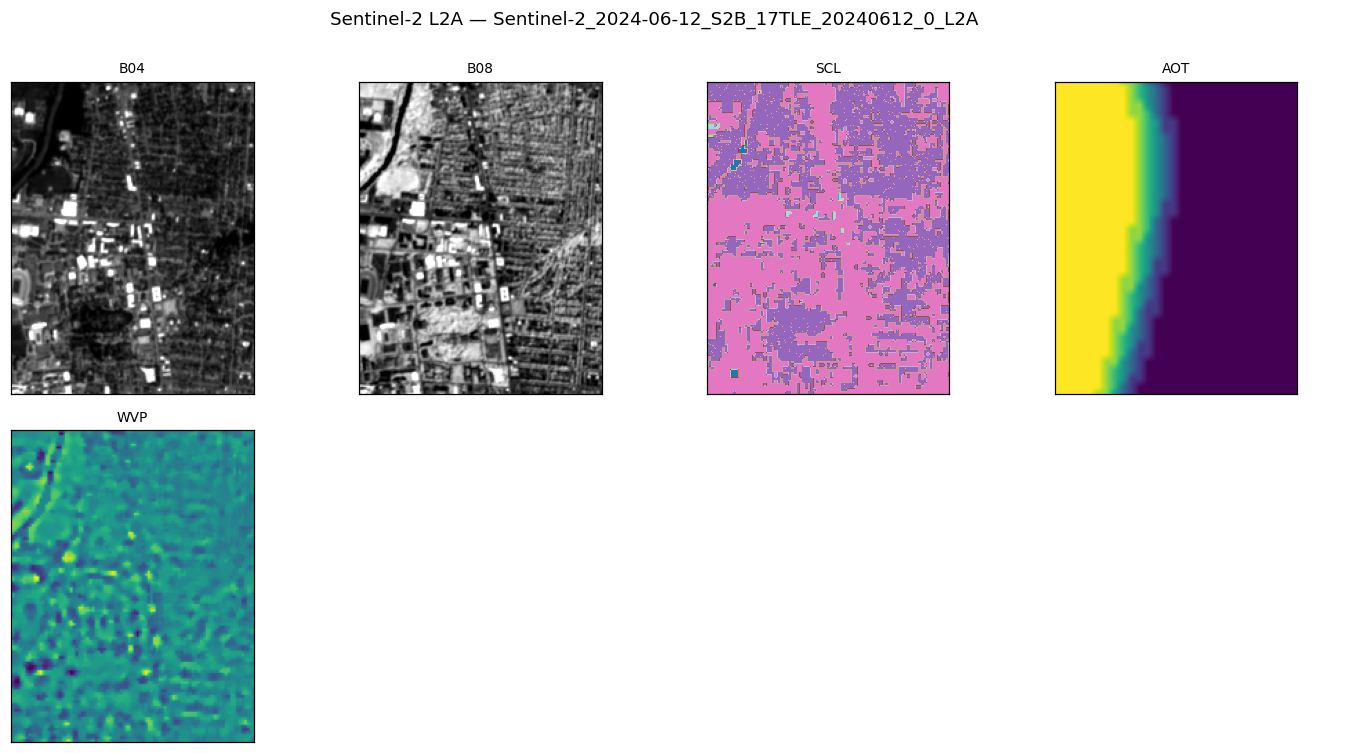

In [9]:
# --- visualise: RGB-ish (B04 alone since we don't have B02/B03 by default) + each band ---
cmap_s2 = {"B04": "gray", "B08": "gray", "SCL": "tab20", "AOT": "viridis", "WVP": "viridis"}
show_bands(arr_s2, descs_s2,
           f"Sentinel-2 L2A — {S2_DIR.name}",
           cmap_per_band=cmap_s2)

The **SCL** (Scene Classification Layer) band uses integer class codes
3 = cloud shadow, 8/9 = cloud, 10 = cirrus, etc. — that's what the tiler
will use in Section 5 to mask cloudy pixels. **AOT** (aerosol optical
thickness) and **WVP** (water vapour) are atmospheric helpers; you usually
don't train on them directly but they're handy diagnostics.

### 3b. Sentinel-2 L1C — top-of-atmosphere

L1C is *top-of-atmosphere* reflectance — the same image as L2A but without
the atmospheric correction (and without SCL, so no per-pixel cloud mask).
Useful when you want to do your own atmospheric correction, train on
foundation models that were pre-trained on L1C, or push back to the early
years of the archive when L2A was patchy.

>>> Sentinel-2 L1C <<<
ℹ️  auto-provider: 'Sentinel-2-L1C' -> 'earthsearch'
🔎 Searching earthsearch for 'sentinel-2-l1c' over [-83.02, 39.995, -83.0, 40.015] in 2024-06-01..2024-06-30 with cloud<20% ...


✅ Selected scene S2B_17TLE_20240612_0_L1C (2024-06-12) cloud=0.0%


🗺️ Output grid: 176x226 px at 10 m in EPSG:32617
  ↓   B04  (       red)  bilinear  B04.jp2


  ↓   B08  (       nir)  bilinear  B08.jp2


fetched in 26.2s
scene folder: Sentinel-2-L1C_2024-06-12_S2B_17TLE_20240612_0_L1C 

  file       : data/Sentinel-2-L1C_2024-06-12_S2B_17TLE_20240612_0_L1C/response.tiff
  bands      : 2  ->  ['B04', 'B08']
  shape (C,H,W) = (2, 226, 176)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 9.98489 x 9.99365 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
               B04  min= 1374.402  max= 8879.803  mean= 2232.371  NaN=  0.0%
               B08  min= 1582.543  max= 9247.708  mean= 3459.638  NaN=  0.0%


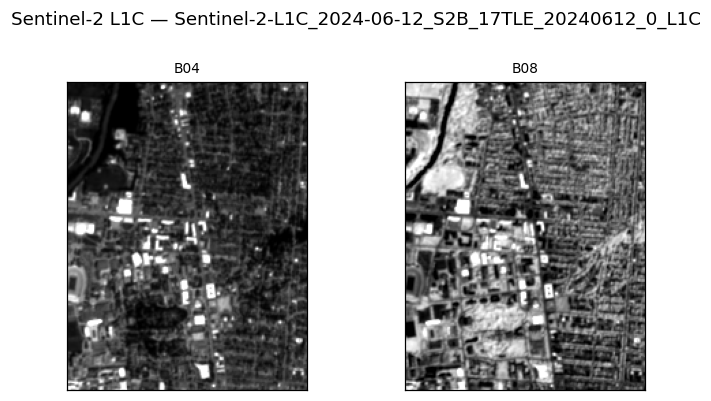

In [10]:
print(">>> Sentinel-2 L1C <<<")
t0 = time.time()
try:
    _data, _bands = fetch_sentinel_data(
        "Sentinel-2-L1C", None, TIME_RANGE_OPTICAL, ROI,
        resolution=RES_S2, save_folder=str(DATA),
        max_cloud_coverage=MAX_CLOUD, provider="auto",
    )
    print(f"fetched in {time.time()-t0:.1f}s")
    L1C_DIR = sorted(DATA.glob("Sentinel-2-L1C_*"), key=os.path.getmtime)[-1]
    print("scene folder:", L1C_DIR.name, "\n")
    arr_l1c, descs_l1c, prof_l1c, bb_l1c, xf_l1c, crs_l1c, tf_l1c = open_response(L1C_DIR)
    print_response_summary(arr_l1c, descs_l1c, prof_l1c, bb_l1c, xf_l1c, crs_l1c, tf_l1c)
    show_bands(arr_l1c, descs_l1c, f"Sentinel-2 L1C — {L1C_DIR.name}",
               cmap_per_band={b: "gray" for b in descs_l1c})
except Exception as e:
    print(f"L1C fetch skipped: {type(e).__name__}: {e}")
    L1C_DIR = None

### 3c. Sentinel-1 RTC — SAR backscatter (sees through clouds)

Sentinel-1 is **synthetic-aperture radar (SAR)** — active microwave imaging
that works at night and through clouds. The pipeline pulls the
**radiometric-terrain-corrected (RTC)** product from Planetary Computer
(Earth Search only has raw GRD, which lacks a usable CRS). The two bands
are dual-polarisation backscatter:

- **VV** — vertical transmit, vertical receive. Bright on rough surfaces.
- **VH** — vertical transmit, horizontal receive. Sensitive to vegetation
  volume scattering.

Values are linear (not dB). For visualisation we stretch each band to
percentile [2, 98] so the urban/water/vegetation contrast pops out.

>>> Sentinel-1 RTC <<<
ℹ️  auto-provider: 'Sentinel-1' -> 'planetary_computer'
🔎 Searching planetary_computer for 'sentinel-1-rtc' over [-83.02, 39.995, -83.0, 40.015] in 2024-06-01..2024-06-30 ...


✅ Selected scene S1A_IW_GRDH_1SDV_20240629T233207_20240629T233232_054545_06A36D_rtc (2024-06-29)


🗺️ Output grid: 176x226 px at 10 m in EPSG:32617


  ↓    VV  (        vv)  bilinear  iw-vv.rtc.tiff


  ↓    VH  (        vh)  bilinear  iw-vh.rtc.tiff


fetched in 3.0s
  file       : data/Sentinel-1_2024-06-29_S1A_IW_GRDH_1SDV_20240629T233207_20240629T233232_054545_06A36D_rtc/response.tiff
  bands      : 2  ->  ['VV', 'VH']
  shape (C,H,W) = (2, 226, 176)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 9.98489 x 9.99365 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
                VV  min=    0.012  max= 1297.900  mean=    2.716  NaN=  0.0%
                VH  min=    0.003  max=    8.639  mean=    0.065  NaN=  0.0%


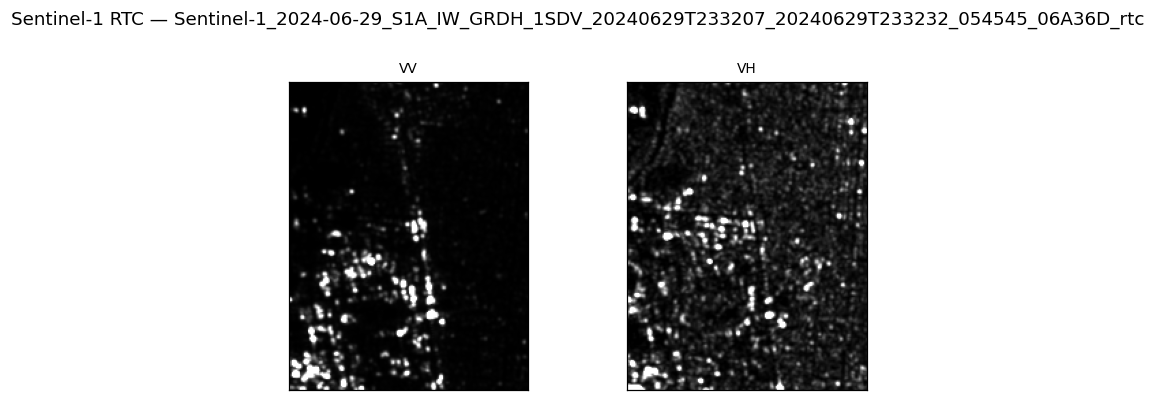

In [11]:
print(">>> Sentinel-1 RTC <<<")
t0 = time.time()
try:
    _data, _bands = fetch_sentinel_data(
        "Sentinel-1", None, TIME_RANGE_RADAR, ROI,
        resolution=RES_S1, save_folder=str(DATA),
        max_cloud_coverage=MAX_CLOUD,    # ignored for SAR
        provider="auto",
    )
    print(f"fetched in {time.time()-t0:.1f}s")
    S1_DIR = sorted(DATA.glob("Sentinel-1_*"), key=os.path.getmtime)[-1]
    arr_s1, descs_s1, prof_s1, bb_s1, xf_s1, crs_s1, tf_s1 = open_response(S1_DIR)
    print_response_summary(arr_s1, descs_s1, prof_s1, bb_s1, xf_s1, crs_s1, tf_s1)
    show_bands(arr_s1, descs_s1, f"Sentinel-1 RTC — {S1_DIR.name}",
               cmap_per_band={b: "gray" for b in descs_s1})
except Exception as e:
    print(f"Sentinel-1 fetch skipped: {type(e).__name__}: {e}")
    S1_DIR = None

### 3d. Landsat 8-9 Collection 2 Level-2

Landsat-8 and -9 fly together with a combined 8-day revisit. The pipeline
defaults to **B04 (red) + B05 (NIR) + BQA** at 30 m. The BQA (`qa_pixel`)
band is a **bit-packed** quality mask — bit 1 = dilated cloud, bit 3 =
cloud, bit 4 = cloud shadow. The tiler decodes this for cloud masking in
Section 5.

>>> Landsat 8/9 C2 L2 <<<
ℹ️  auto-provider: 'Landsat' -> 'planetary_computer'
🔎 Searching planetary_computer for 'landsat-c2-l2' over [-83.02, 39.995, -83.0, 40.015] in 2024-05-01..2024-09-30 with cloud<40% ...


✅ Selected scene LC09_L2SP_019032_20240914_02_T1 (2024-09-14) cloud=0.7%


🗺️ Output grid: 59x76 px at 30 m in EPSG:32617


  ↓   B04  (       red)  bilinear  LC09_L2SP_019032_20240914_20240915_02_T1_SR_B4.TIF


  ↓   B05  (     nir08)  bilinear  LC09_L2SP_019032_20240914_20240915_02_T1_SR_B5.TIF


  ↓   BQA  (  qa_pixel)  nearest   LC09_L2SP_019032_20240914_20240915_02_T1_QA_PIXEL.TIF


fetched in 3.6s
  file       : data/Landsat_2024-09-14_LC09_L2SP_019032_20240914_02_T1/response.tiff
  bands      : 3  ->  ['B04', 'B05', 'BQA']
  shape (C,H,W) = (3, 76, 59)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 29.7854 x 29.7179 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
               B04  min= 8455.133  max=24190.912  mean=11189.131  NaN=  0.0%
               B05  min= 9623.213  max=28666.719  mean=15165.445  NaN=  0.0%
               BQA  min=21824.000  max=21952.000  mean=21824.172  NaN=  0.0%


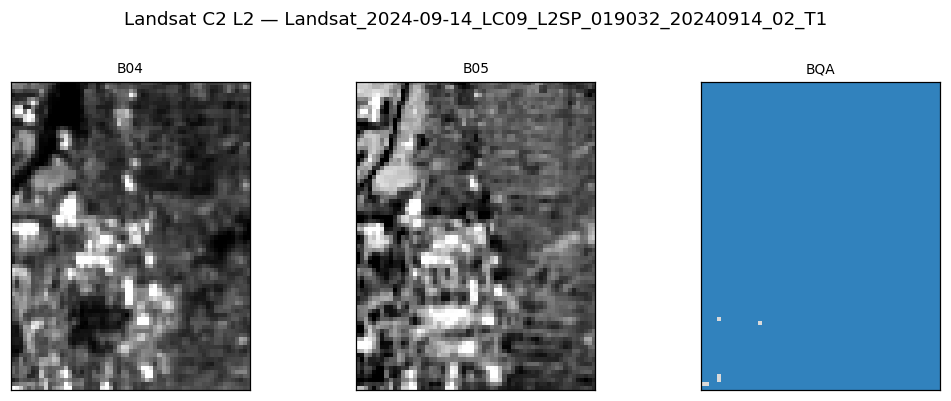

In [12]:
print(">>> Landsat 8/9 C2 L2 <<<")
t0 = time.time()
try:
    _data, _bands = fetch_sentinel_data(
        "Landsat", None, TIME_RANGE_LANDSAT, ROI,
        resolution=RES_LSC, save_folder=str(DATA),
        max_cloud_coverage=0.40, provider="auto",
    )
    print(f"fetched in {time.time()-t0:.1f}s")
    LSC_DIR = sorted(DATA.glob("Landsat_*"), key=os.path.getmtime)[-1]
    arr_lsc, descs_lsc, prof_lsc, bb_lsc, xf_lsc, crs_lsc, tf_lsc = open_response(LSC_DIR)
    print_response_summary(arr_lsc, descs_lsc, prof_lsc, bb_lsc, xf_lsc, crs_lsc, tf_lsc)
    show_bands(arr_lsc, descs_lsc, f"Landsat C2 L2 — {LSC_DIR.name}",
               cmap_per_band={"B04": "gray", "B05": "gray", "BQA": "tab20c"})
except Exception as e:
    print(f"Landsat fetch skipped: {type(e).__name__}: {e}")
    LSC_DIR = None

### 3e. Copernicus DEM — 30 m global elevation (static)

DEMs are *static* layers — there's no time component. The pipeline ignores
`TIME_RANGE` for static missions, deduplicates by spatial tile, and
mosaics whatever tiles intersect the AOI onto the requested grid. The
single band is just **DEM** (elevation in metres above ellipsoid).

>>> Copernicus DEM <<<
ℹ️  auto-provider: 'Copernicus-DEM' -> 'earthsearch'
🔎 Searching earthsearch for 'cop-dem-glo-30' over [-83.02, 39.995, -83.0, 40.015] (static) ...


✅ Static mosaic: 4 tile(s) covering the AOI (latest version 2021-04-22)


   (source CRS is geographic; output in EPSG:32617 so resolution=30 m is correct)
🗺️ Output grid: 59x76 px at 30 m in EPSG:32617
  ↓   DEM  (      data)  bilinear  mosaic of 4 tile(s)


fetched in 5.1s
  file       : data/Copernicus-DEM_cop-dem-glo-30_mosaic_2021-04-22/response.tiff
  bands      : 1  ->  ['DEM']
  shape (C,H,W) = (1, 76, 59)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 29.7854 x 29.7179 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
               DEM  min=  210.827  max=  264.359  mean=  237.222  NaN=  0.0%


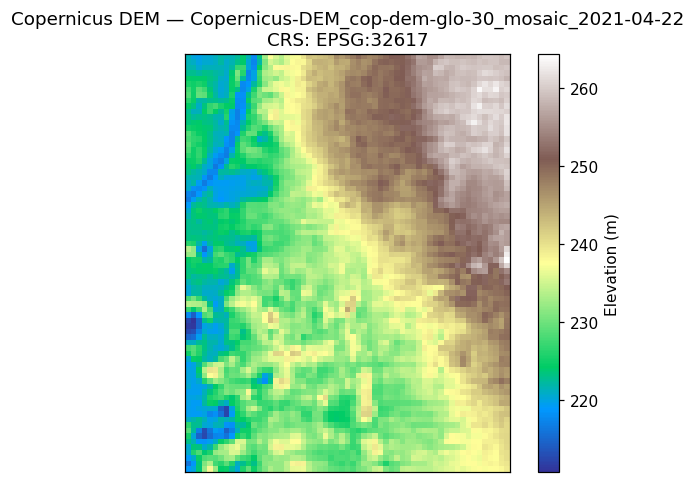

In [13]:
print(">>> Copernicus DEM <<<")
t0 = time.time()
_data, _bands = fetch_sentinel_data(
    "Copernicus-DEM", None, TIME_RANGE_OPTICAL, ROI,
    resolution=RES_DEM, save_folder=str(DATA),
    max_cloud_coverage=MAX_CLOUD, provider="auto",
)
print(f"fetched in {time.time()-t0:.1f}s")
DEM_DIR = sorted(DATA.glob("Copernicus-DEM_*"), key=os.path.getmtime)[-1]
arr_dem, descs_dem, prof_dem, bb_dem, xf_dem, crs_dem, tf_dem = open_response(DEM_DIR)
print_response_summary(arr_dem, descs_dem, prof_dem, bb_dem, xf_dem, crs_dem, tf_dem)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(arr_dem[0], cmap="terrain")
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title(f"Copernicus DEM — {DEM_DIR.name}\nCRS: {crs_dem}")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Notice in the metadata block that `static = True` and `mosaic_tiles ≥ 1`:
the pipeline pulled however many 1° DEM tiles touched our AOI and welded
them together onto the output grid. Same applies to WorldCover below.

### 3f. ESA WorldCover — 10 m global land cover (static)

WorldCover is a global, **categorical** 10 m land-cover map (2020 + 2021
versions). The pipeline picks the latest version per tile and uses
**nearest-neighbour resampling** so class IDs are preserved exactly
(10 = tree cover, 20 = shrubland, 30 = grassland, 40 = cropland,
50 = built-up, 60 = bare/sparse vegetation, 70 = snow/ice, 80 = permanent
water, 90 = herbaceous wetland, 95 = mangroves, 100 = moss/lichen).

>>> ESA WorldCover <<<
ℹ️  auto-provider: 'ESA-WorldCover' -> 'planetary_computer'
🔎 Searching planetary_computer for 'esa-worldcover' over [-83.02, 39.995, -83.0, 40.015] (static) ...


✅ Static mosaic: 1 tile(s) covering the AOI (latest version n/a)


   (source CRS is geographic; output in EPSG:32617 so resolution=10 m is correct)
🗺️ Output grid: 176x226 px at 10 m in EPSG:32617


  ↓  LULC  (       map)  nearest   ESA_WorldCover_10m_2021_v200_N39W084_Map.tif


fetched in 2.2s
  file       : data/ESA-WorldCover_esa-worldcover_mosaic_static/response.tiff
  bands      : 1  ->  ['LULC']
  shape (C,H,W) = (1, 226, 176)   dtype=float32
  CRS        : EPSG:32617
  pixel size : 9.98489 x 9.99365 (CRS units, usually metres)
  extent     : 327554.5, 4429118.0, 329311.9, 4431376.5
              LULC  min=   10.000  max=   80.000  mean=   39.671  NaN=  0.0%


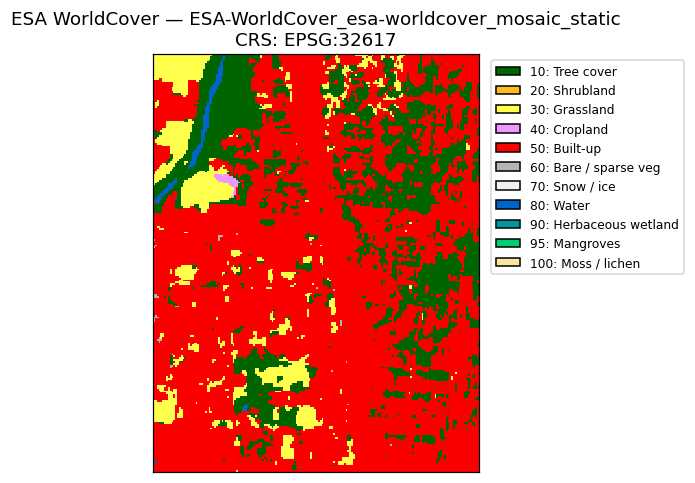


Pixel counts by class:
    10  Tree cover               8845  ( 22.2%)
    30  Grassland                3174  (  8.0%)
    40  Cropland                   66  (  0.2%)
    50  Built-up                27429  ( 69.0%)
    60  Bare / sparse veg          39  (  0.1%)
    80  Water                     223  (  0.6%)


In [14]:
print(">>> ESA WorldCover <<<")
t0 = time.time()
_data, _bands = fetch_sentinel_data(
    "ESA-WorldCover", None, TIME_RANGE_OPTICAL, ROI,
    resolution=RES_LULC, save_folder=str(DATA),
    max_cloud_coverage=MAX_CLOUD, provider="auto",
)
print(f"fetched in {time.time()-t0:.1f}s")
LULC_DIR = sorted(DATA.glob("ESA-WorldCover_*"), key=os.path.getmtime)[-1]
arr_lulc, descs_lulc, prof_lulc, bb_lulc, xf_lulc, crs_lulc, tf_lulc = open_response(LULC_DIR)
print_response_summary(arr_lulc, descs_lulc, prof_lulc, bb_lulc, xf_lulc, crs_lulc, tf_lulc)

# --- a categorical palette + legend ---
LULC_CLASSES = {
    10: ("Tree cover",       "#006400"),
    20: ("Shrubland",        "#FFBB22"),
    30: ("Grassland",        "#FFFF4C"),
    40: ("Cropland",         "#F096FF"),
    50: ("Built-up",         "#FA0000"),
    60: ("Bare / sparse veg","#B4B4B4"),
    70: ("Snow / ice",       "#F0F0F0"),
    80: ("Water",            "#0064C8"),
    90: ("Herbaceous wetland","#0096A0"),
    95: ("Mangroves",        "#00CF75"),
    100:("Moss / lichen",    "#FAE6A0"),
}
codes = sorted(LULC_CLASSES.keys())
code_to_idx = {c: i for i, c in enumerate(codes)}
arr_idx = np.full(arr_lulc[0].shape, -1, dtype=int)
for c, i in code_to_idx.items():
    arr_idx[arr_lulc[0] == c] = i

palette = ListedColormap([LULC_CLASSES[c][1] for c in codes])
palette.set_bad("white")  # for -1 / NaN
masked = np.ma.masked_less(arr_idx, 0)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.imshow(masked, cmap=palette, vmin=-0.5, vmax=len(codes) - 0.5, interpolation="nearest")
ax.set_title(f"ESA WorldCover — {LULC_DIR.name}\nCRS: {crs_lulc}")
ax.set_xticks([]); ax.set_yticks([])

# class legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=LULC_CLASSES[c][1], edgecolor="k",
                 label=f"{c}: {LULC_CLASSES[c][0]}") for c in codes]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

# class-wise pixel counts so we can sanity-check the figure
unique, counts = np.unique(arr_lulc[0], return_counts=True)
print("\nPixel counts by class:")
for u, n in zip(unique, counts):
    u = int(u)
    name = LULC_CLASSES.get(u, ("?", ""))[0]
    print(f"  {u:>4d}  {name:<20s}  {n:>7d}  ({100*n/counts.sum():5.1f}%)")

## 4. The commercial path — PlanetScope

PlanetScope is **commercial** ~3 m optical imagery from Planet Labs. The
free path stops here — to follow along you need an API key in `.env` as
`PL_API_KEY=...`. The pipeline ships two profiles:

- **`PlanetScope-4b`** — the legacy 4-band Dove/SuperDove archive
  (B, G, R, NIR), back to ~2016. Best for long time series.
- **`PlanetScope-8b`** — SuperDove only (PSB.SD, March 2022+) with
  eight bands (Coastal Blue, B, Green I, G, Yellow, R, RedEdge, NIR).
  Spectral coverage close to Sentinel-2's; the right choice for modern
  multispectral modeling.

Both come with a **UDM2** (Usable Data Mask v2) raster: 8 categorical
bands telling you whether each pixel is clear / snow / shadow / haze /
cloud / etc. The pipeline adds `udm2_clear` to the response cube so the
tiler can cloud-mask just like it does for SCL and BQA.

The cell below runs only if `PL_API_KEY` is set — otherwise it prints a
short explanation and moves on. Planet orders are **asynchronous**
(submit -> poll -> download), so expect several minutes if you enable it.

In [15]:
PL_OK = bool(os.environ.get("PL_API_KEY"))
if not PL_OK:
    print("PL_API_KEY is not set — PlanetScope cells are skipped.")
    print("To try them, get a key from https://www.planet.com/account/#/user-settings")
    print("and put it in a `.env` file at the repo root:  PL_API_KEY=...")
    print("Note: Planet orders are asynchronous and can take several minutes.")
else:
    print("PL_API_KEY detected — running PlanetScope-4b fetch.")
    try:
        t0 = time.time()
        _data, _bands = fetch_sentinel_data(
            "PlanetScope-4b", None, TIME_RANGE_OPTICAL, ROI,
            resolution=3, save_folder=str(DATA),
            max_cloud_coverage=MAX_CLOUD, provider="planet",
        )
        print(f"fetched in {time.time()-t0:.1f}s")
        PS_DIR = sorted(DATA.glob("PlanetScope-4b_*"), key=os.path.getmtime)[-1]
        arr_ps, descs_ps, prof_ps, bb_ps, xf_ps, crs_ps, tf_ps = open_response(PS_DIR)
        print_response_summary(arr_ps, descs_ps, prof_ps, bb_ps, xf_ps, crs_ps, tf_ps)
        show_bands(arr_ps, descs_ps, f"PlanetScope-4b — {PS_DIR.name}",
                   cmap_per_band={"R": "gray", "NIR": "gray",
                                  "udm2_clear": "gray",
                                  "udm2_shadow": "gray",
                                  "udm2_cloud": "gray"})
    except Exception as e:
        print(f"PlanetScope fetch failed: {type(e).__name__}: {e}")

PL_API_KEY is not set — PlanetScope cells are skipped.
To try them, get a key from https://www.planet.com/account/#/user-settings
and put it in a `.env` file at the repo root:  PL_API_KEY=...
Note: Planet orders are asynchronous and can take several minutes.


## 5. Cloud masking up close

Two of our missions — Sentinel-2 L2A and Landsat — ship a per-pixel
quality band that flags clouds and shadows. The pipeline knows how to
decode both. Let's visualise them next to a stretched intensity image so
you can see exactly which pixels are about to be masked.

- **SCL** (Sentinel-2 L2A scene classification): integer class codes.
  Classes 3 / 8 / 9 / 10 = shadow / cloud / cloud high / cirrus.
- **BQA / qa_pixel** (Landsat C2 L2): bit-packed. Bits 1 / 3 / 4 =
  dilated cloud / cloud / cloud shadow.
- **UDM2 band 1** (PlanetScope): 1 = clear, 0 = anything else.

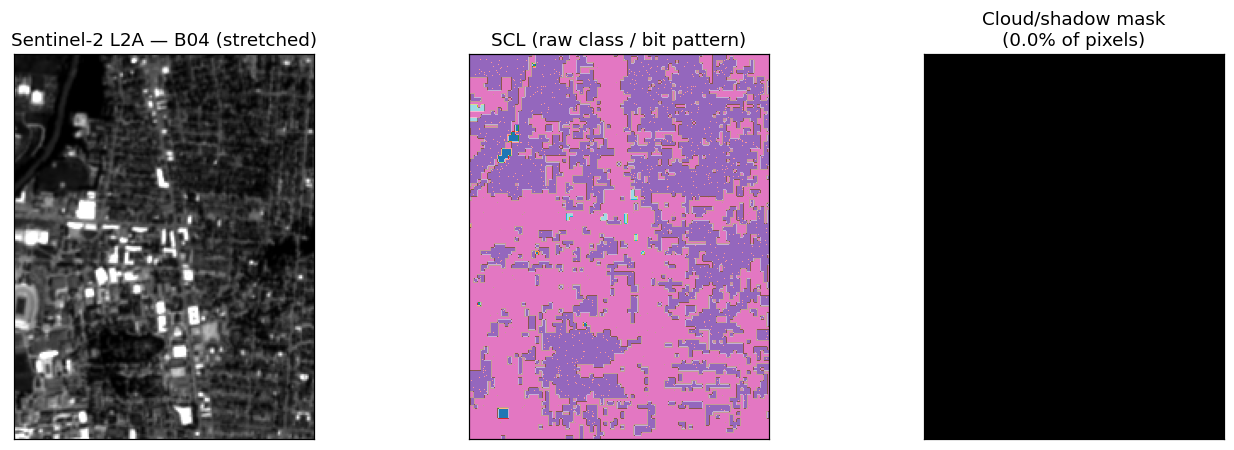

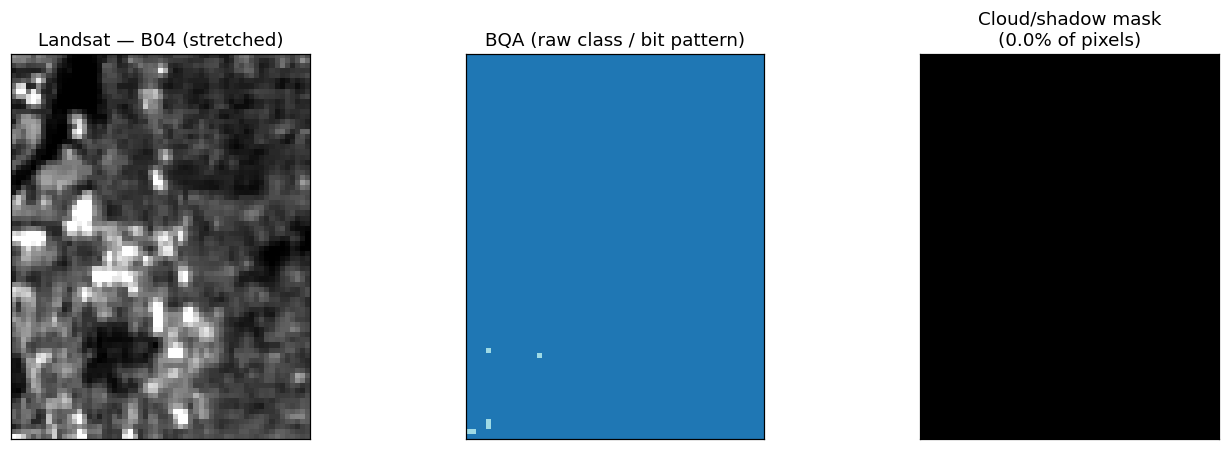

In [16]:
def plot_cloud_pair(name, arr, descs, intensity_band, qa_band, decode_qa):
    '''Side-by-side: stretched intensity band, decoded cloud mask, fraction stats.'''
    bi_int = descs.index(intensity_band)
    bi_qa  = descs.index(qa_band)
    intensity = stretch01(arr[bi_int])
    qa        = arr[bi_qa]
    mask      = decode_qa(qa)
    pct = 100.0 * mask.sum() / mask.size
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
    axes[0].imshow(intensity, cmap="gray")
    axes[0].set_title(f"{name} — {intensity_band} (stretched)")
    axes[1].imshow(qa, cmap="tab20")
    axes[1].set_title(f"{qa_band} (raw class / bit pattern)")
    axes[2].imshow(mask, cmap="Greys_r")
    axes[2].set_title(f"Cloud/shadow mask\n({pct:.1f}% of pixels)")
    for a in axes:
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
    return mask


# --- Sentinel-2 SCL ---
def decode_scl(qa):
    classes = np.rint(qa).astype(np.int64)
    return np.isin(classes, [3, 8, 9, 10])

mask_s2 = plot_cloud_pair("Sentinel-2 L2A", arr_s2, descs_s2,
                          intensity_band="B04", qa_band="SCL",
                          decode_qa=decode_scl)


# --- Landsat BQA (only if Landsat fetched OK) ---
if LSC_DIR is not None and "BQA" in descs_lsc:
    def decode_bqa(qa):
        qa = np.rint(qa).astype(np.int64)
        m = np.zeros(qa.shape, dtype=bool)
        for bit in (1, 3, 4):
            m |= ((qa >> bit) & 1).astype(bool)
        return m
    mask_lsc = plot_cloud_pair("Landsat", arr_lsc, descs_lsc,
                               intensity_band="B04", qa_band="BQA",
                               decode_qa=decode_bqa)

The middle panel shows the raw quality band — it's most useful for
debugging (you can see *which* class triggered the mask). The right panel
is the binary mask the tiler will apply when you pass `cloud_mask=True`:
those pixels get set to NaN in the data bands (the QA band itself is
preserved). NaN-handling then decides what happens to the tile: drop it,
fill the holes, or keep the tile and append a validity-mask band — see
Section 6.

## 6. NaN handling — `drop`, `interpolate`, `mask`

After cloud masking (or just at the edges of a scene mosaic) you'll have
tiles with some NaN pixels. `tile_geotiff` offers three policies:

- **`drop`** — strict. Any NaN in a tile and the whole tile is skipped.
  Best when you want a perfectly clean training set, can afford to lose
  some area, and don't want to pollute models with imputed values.
- **`interpolate`** — fill NaN pixels from their nearest valid neighbour
  if they're within `nan_interp_max_dist` pixels (default 3). Good for
  isolated holes and one-pixel mosaic seams. Tiles whose holes are too
  big or too far from real pixels are still dropped.
- **`mask`** — keep the tile, replace NaNs with 0 in the data bands, and
  append a binary `valid_mask` channel so your loss can ignore them
  ("pad-and-ignore"). The standard approach for U-Net-style segmentation.

Below we tile the same Sentinel-2 scene three times with the same
`cloud_mask=True` setting and compare the resulting tile counts.

In [17]:
S2_TILES_DIR = TILES / "s2"
if S2_TILES_DIR.exists():
    shutil.rmtree(S2_TILES_DIR)

# tile size and stride chosen for the tiny AOI:
# the response.tiff is ~200x200 px so we use 64-px tiles for several samples.
TILE_SIZE  = 64
STRIDE     = 64

def count_tiles(out_dir):
    out_dir = Path(out_dir)
    return {sub: len(list((out_dir / sub).glob("*.tif")))
            for sub in ("train", "val", "test")}


results = {}
for mode in ("drop", "interpolate", "mask"):
    out = S2_TILES_DIR / mode
    print(f"\n--- nan_handling = {mode!r} ---")
    tile_geotiff(
        input_tiff=tiff_s2,
        output_dir=str(out),
        tile_size=TILE_SIZE, stride=STRIDE,
        augment=False, output_mode="geotiff",
        train_val_test_split=(0.8, 0.1, 0.1),
        split_method="random",
        nan_handling=mode,
        cloud_mask=True,
    )
    results[mode] = count_tiles(out)

print("\nTile counts per nan_handling mode (cloud_mask=True):")
print(f"  {'mode':>12s}  {'train':>6s}  {'val':>6s}  {'test':>6s}  {'total':>6s}")
for mode, c in results.items():
    t = sum(c.values())
    print(f"  {mode:>12s}  {c['train']:>6d}  {c['val']:>6d}  {c['test']:>6d}  {t:>6d}")


--- nan_handling = 'drop' ---
🚫 Padding disabled — last partial tiles may be dropped.
☁️  cloud_mask=True: NaN-ing cloudy pixels using SCL


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 154.67it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2/drop/tiles_metadata.csv
🧩 Total tiles created: 6 | split_method='random' | nan_handling='drop'
   train=4  val=2  test=0

--- nan_handling = 'interpolate' ---
🚫 Padding disabled — last partial tiles may be dropped.
☁️  cloud_mask=True: NaN-ing cloudy pixels using SCL


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 215.85it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2/interpolate/tiles_metadata.csv
🧩 Total tiles created: 6 | split_method='random' | nan_handling='interpolate'
   train=4  val=1  test=1

--- nan_handling = 'mask' ---
🚫 Padding disabled — last partial tiles may be dropped.
☁️  cloud_mask=True: NaN-ing cloudy pixels using SCL


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 226.98it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2/mask/tiles_metadata.csv
🧩 Total tiles created: 6 | split_method='random' | nan_handling='mask'
   train=5  val=1  test=0

Tile counts per nan_handling mode (cloud_mask=True):
          mode   train     val    test   total
          drop       4       2       0       6
   interpolate       4       1       1       6
          mask       5       1       0       6


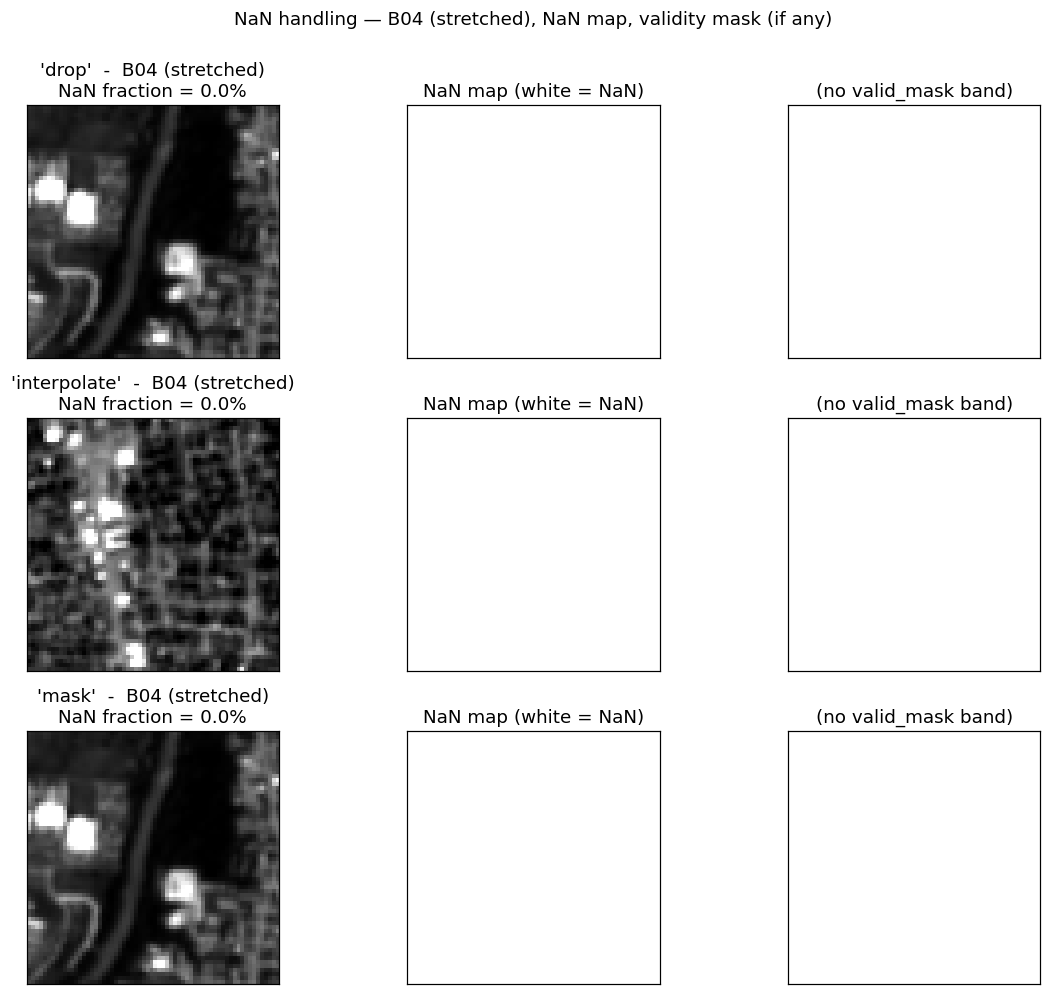

In [18]:
# --- visualise: for ONE tile, show before/after NaN handling in each mode ---
def open_tile(p):
    with rasterio.open(p) as src:
        return src.read(), list(src.descriptions or []), src.tags()

# pick a tile that exists in interpolate or mask mode (drop may discard it)
def first_tile(out_dir):
    for sub in ("train", "val", "test"):
        cands = sorted(Path(out_dir).joinpath(sub).glob("*.tif"))
        if cands:
            return cands[0]
    return None

# Build a synthetic NaN-pattern visual: load a tile from each mode and
# compare the B04 band + the NaN map (+ valid_mask if mask mode).
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
fig.suptitle("NaN handling — B04 (stretched), NaN map, validity mask (if any)", y=1.00)

for row, mode in enumerate(("drop", "interpolate", "mask")):
    tp = first_tile(S2_TILES_DIR / mode)
    if tp is None:
        for c in range(3): axes[row][c].axis("off")
        axes[row][0].set_title(f"{mode!r}: no tiles kept")
        continue
    arr, descs, tags = open_tile(tp)
    bi_b04 = descs.index("B04")
    b04 = arr[bi_b04]
    nan_map = np.isnan(b04)
    axes[row][0].imshow(stretch01(b04), cmap="gray")
    axes[row][0].set_title(f"{mode!r}  -  B04 (stretched)\nNaN fraction = {100*nan_map.mean():.1f}%")
    axes[row][1].imshow(nan_map, cmap="Greys")
    axes[row][1].set_title("NaN map (white = NaN)")
    if "valid_mask" in descs:
        bi_vm = descs.index("valid_mask")
        axes[row][2].imshow(arr[bi_vm], cmap="Greys_r")
        axes[row][2].set_title("appended valid_mask band")
    else:
        axes[row][2].imshow(np.zeros_like(b04), cmap="Greys")
        axes[row][2].set_title("(no valid_mask band)")
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

Read the three rows top to bottom:

- **`drop`** — every kept tile is completely NaN-free, by construction.
- **`interpolate`** — the NaN map should be near-empty for the kept tiles
  (any small holes were filled from neighbours). The pipeline reports how
  many pixels it filled per tile in the embedded `tile_n_filled` tag.
- **`mask`** — NaN pixels are replaced by zeros in the data bands and the
  appended `valid_mask` band remembers where they were. Use that band as
  a loss mask in PyTorch / TensorFlow.

Rule of thumb: start with `interpolate` for small ROIs and `mask` for
segmentation models; reserve `drop` for very clean training sets where
you have plenty of area.

## 7. Tiling — with and without overlap

Models train on small square patches, not on whole scenes. `tile_geotiff`
slides a window of `tile_size` pixels across the GeoTIFF in steps of
`stride` pixels:

- **`stride = tile_size`** — disjoint tiles. Simplest, fastest, smallest
  dataset. Adjacent tiles share zero pixels.
- **`stride = tile_size // 2`** — 50% overlap. ~4× as many tiles, each
  pixel appears in up to 4 tiles. Useful when you want to augment the
  effective training set or to do test-time tiling with averaging in the
  overlaps.

Below we tile the Sentinel-2 scene both ways and overlay the tile grid on
the source image, then show a 4×4 sample of the resulting tiles.

In [19]:
# Tile twice: no overlap and 50% overlap, no cloud masking, no augmentation.
for tag, stride in (("no_overlap", TILE_SIZE), ("overlap50", TILE_SIZE // 2)):
    out = TILES / f"s2_{tag}"
    if out.exists(): shutil.rmtree(out)
    tile_geotiff(
        input_tiff=tiff_s2, output_dir=str(out),
        tile_size=TILE_SIZE, stride=stride,
        augment=False, output_mode="geotiff",
        train_val_test_split=(1.0, 0.0, 0.0),
        split_method="random", nan_handling="mask",
    )

# Count tiles
n_no  = len(list((TILES / "s2_no_overlap").glob("train/*.tif")))
n_ov  = len(list((TILES / "s2_overlap50").glob("train/*.tif")))
print(f"\nTile counts:  no_overlap = {n_no}   |   50% overlap = {n_ov}   "
      f"(ratio = {n_ov / max(n_no,1):.1f}x)")

🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 240.52it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2_no_overlap/tiles_metadata.csv
🧩 Total tiles created: 6 | split_method='random' | nan_handling='mask'
   train=6  val=0  test=0
🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 203.20it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2_overlap50/tiles_metadata.csv
🧩 Total tiles created: 24 | split_method='random' | nan_handling='mask'
   train=24  val=0  test=0

Tile counts:  no_overlap = 6   |   50% overlap = 24   (ratio = 4.0x)


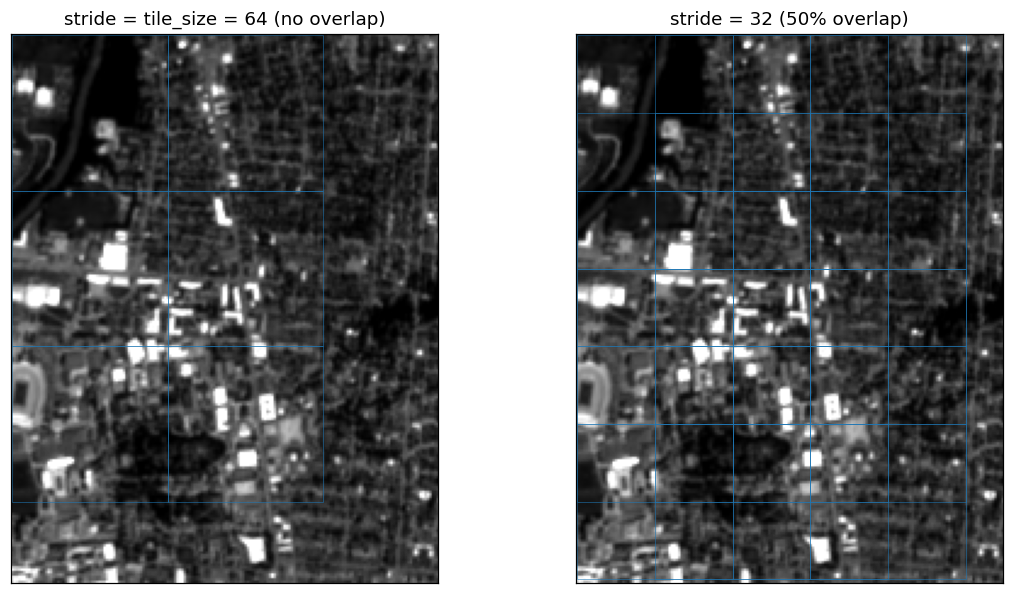

In [20]:
# --- overlay tile grid on source image ---
def tile_grid_overlay(arr, descs, tiff_path, tile_size, stride, ax, title):
    bi = descs.index("B04") if "B04" in descs else 0
    ax.imshow(stretch01(arr[bi]), cmap="gray")
    H, W = arr.shape[-2:]
    for y in range(0, H - tile_size + 1, stride):
        for x in range(0, W - tile_size + 1, stride):
            rect = Rectangle((x, y), tile_size, tile_size,
                             fill=False, edgecolor="#1f77b4", lw=0.6, alpha=0.6)
            ax.add_patch(rect)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
tile_grid_overlay(arr_s2, descs_s2, tiff_s2, TILE_SIZE, TILE_SIZE,
                  axes[0], f"stride = tile_size = {TILE_SIZE} (no overlap)")
tile_grid_overlay(arr_s2, descs_s2, tiff_s2, TILE_SIZE, TILE_SIZE // 2,
                  axes[1], f"stride = {TILE_SIZE//2} (50% overlap)")
plt.tight_layout(); plt.show()

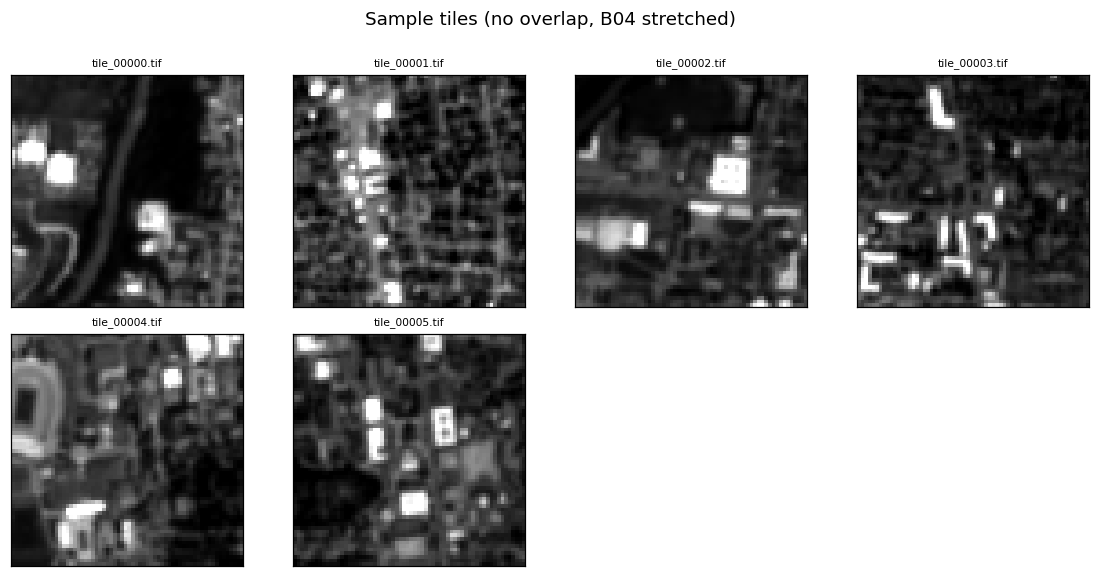

In [21]:
# --- show a 4x4 grid of sample tiles from the no-overlap run ---
tile_paths = sorted((TILES / "s2_no_overlap" / "train").glob("*.tif"))
n_show = min(16, len(tile_paths))
if n_show == 0:
    print("(no tiles to show — AOI may be smaller than tile_size)")
else:
    cols = 4
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.6 * cols, 2.6 * rows))
    for i in range(rows * cols):
        ax = axes.flat[i] if rows > 1 else axes[i]
        if i >= n_show:
            ax.axis("off"); continue
        with rasterio.open(tile_paths[i]) as src:
            arr = src.read()
            descs = list(src.descriptions or [])
        bi = descs.index("B04") if "B04" in descs else 0
        ax.imshow(stretch01(arr[bi]), cmap="gray")
        ax.set_title(os.path.basename(tile_paths[i]), fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Sample tiles (no overlap, B04 stretched)", y=1.00)
    plt.tight_layout(); plt.show()

## 8. Train / val / test split strategies

For satellite imagery, **how** you split tiles matters as much as *what
ratio* you use. Neighbouring tiles often share the same clouds, the same
crop fields, the same shadows — so a random split causes **spatial
data leakage** that makes your test metrics rosier than they should be.

The tiler offers four strategies, all of them reproducible across runs:

- **`random`** — coin flip per tile. Maximum leakage. Use only as a
  sanity-check baseline.
- **`block`** (the **default**) — partition the scene into
  `block_size_tiles × block_size_tiles` blocks (e.g. 4×4 = ~10 km on a
  10 m grid) and assign each whole block to one split. The standard
  spatial-CV approach.
- **`stripes`** — like `block` but 1-D: contiguous N-row (or N-column)
  bands go to one split. Useful when your gradient runs along an axis
  (e.g. elevation, urbanisation).
- **`regions`** — explicit per-split AOIs in the same `aoi.py` spec
  language as `main.py`. The cleanest separation, the most manual setup.

For the **why** behind spatial CV in EO, see
[Hsu & Moortgat 2026 (Remote Sens. 18:1768)](https://www.mdpi.com/search?q=Hsu+Moortgat+bathymetry).

In [22]:
# We need a few more tiles to see the split patterns clearly, so use a denser
# stride for this exercise.
SPLITS_DIR = TILES / "splits"
if SPLITS_DIR.exists(): shutil.rmtree(SPLITS_DIR)

common = dict(
    input_tiff=tiff_s2,
    tile_size=TILE_SIZE, stride=TILE_SIZE // 2,
    augment=False, output_mode="geotiff",
    train_val_test_split=(0.7, 0.15, 0.15),
    nan_handling="mask",
)

print("--- random ---")
tile_geotiff(output_dir=str(SPLITS_DIR / "random"), split_method="random", **common)

print("\n--- block (2x2 tile blocks) ---")
tile_geotiff(output_dir=str(SPLITS_DIR / "block"), split_method="block",
             split_block_size_tiles=2, **common)

print("\n--- stripes (horizontal, 1-tile rows) ---")
tile_geotiff(output_dir=str(SPLITS_DIR / "stripes"), split_method="stripes",
             split_stripe_axis="horizontal", split_stripe_size_tiles=1, **common)

# regions: carve the tiny Columbus AOI into three vertical strips
# (left/middle/right) and assign train/val/test.
roi = ROI
mid_lo, mid_hi = roi[0] + (roi[2] - roi[0]) / 3, roi[0] + 2 * (roi[2] - roi[0]) / 3
print("\n--- regions (left/middle/right vertical strips) ---")
tile_geotiff(
    output_dir=str(SPLITS_DIR / "regions"),
    split_method="regions",
    split_regions={
        "train": {"bbox": [roi[0],  roi[1], mid_lo, roi[3]]},
        "val":   {"bbox": [mid_lo,  roi[1], mid_hi, roi[3]]},
        "test":  {"bbox": [mid_hi,  roi[1], roi[2], roi[3]]},
    },
    **common,
)

print("\nSplit counts per method:")
print(f"  {'method':>10s}  {'train':>6s}  {'val':>6s}  {'test':>6s}")
for m in ("random", "block", "stripes", "regions"):
    c = count_tiles(SPLITS_DIR / m)
    print(f"  {m:>10s}  {c['train']:>6d}  {c['val']:>6d}  {c['test']:>6d}")

--- random ---
🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 183.52it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/splits/random/tiles_metadata.csv
🧩 Total tiles created: 24 | split_method='random' | nan_handling='mask'
   train=15  val=6  test=3

--- block (2x2 tile blocks) ---
🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/6 [00:00<?, ?it/s]

...

100%|██████████| 6/6 [00:00<00:00, 186.61it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/splits/stripes/tiles_metadata.csv
🧩 Total tiles created: 24 | split_method='stripes' | nan_handling='mask'
   train=16  val=0  test=8

--- regions (left/middle/right vertical strips) ---
🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 185.83it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/splits/regions/tiles_metadata.csv
🧩 Total tiles created: 24 | split_method='regions' | nan_handling='mask'
   train=6  val=12  test=6

Split counts per method:
      method   train     val    test
      random      15       6       3
       block      16       0       8
     stripes      16       0       8
     regions       6      12       6


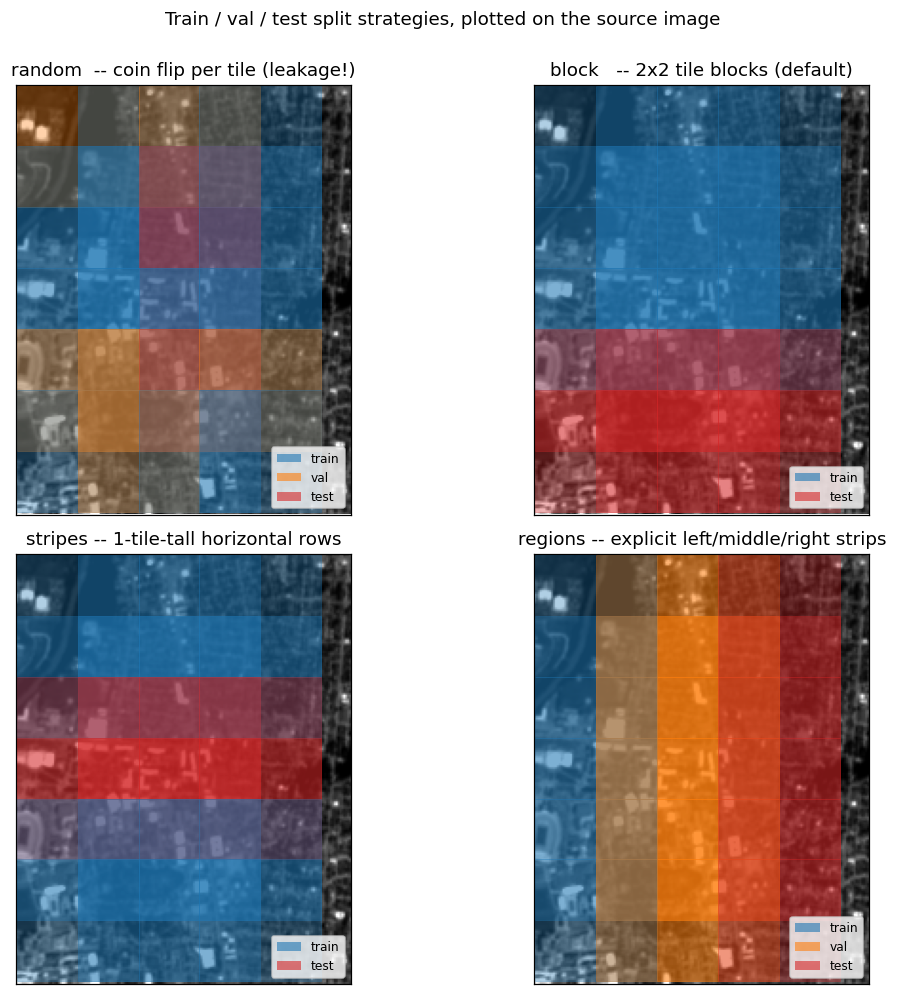

In [23]:
# --- plot the spatial layout of each split method over the source image ---
def plot_split_layout(method, ax, title):
    bi = descs_s2.index("B04")
    ax.imshow(stretch01(arr_s2[bi]), cmap="gray")
    # read the metadata CSV the tiler wrote and colour each tile
    csv_path = SPLITS_DIR / method / "tiles_metadata.csv"
    if not csv_path.exists():
        ax.set_title(f"{title} — no metadata")
        return
    import csv as csv_mod
    color = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#d62728"}
    seen = set()
    with open(csv_path) as f:
        reader = csv_mod.reader(f)
        header = next(reader)
        # columns: filename, x_offset, y_offset, width, height, augmentation, split, ...
        ix, iy, iw, ih, isplit = (header.index(c) for c in ("x_offset", "y_offset", "width", "height", "split"))
        for row in reader:
            # skip augmentations; they share window with their parent
            if row[5] != "none":
                continue
            x, y, w, h = int(row[ix]), int(row[iy]), int(row[iw]), int(row[ih])
            sp = row[isplit]
            if not sp: continue
            seen.add(sp)
            rect = Rectangle((x, y), w, h, fill=True, alpha=0.35,
                             facecolor=color[sp], edgecolor=color[sp], lw=0.5)
            ax.add_patch(rect)
    legend = [Rectangle((0, 0), 1, 1, facecolor=color[s], alpha=0.6, label=s)
              for s in ("train", "val", "test") if s in seen]
    ax.legend(handles=legend, loc="lower right", fontsize=8)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_split_layout("random",  axes[0][0], "random  -- coin flip per tile (leakage!)")
plot_split_layout("block",   axes[0][1], "block   -- 2x2 tile blocks (default)")
plot_split_layout("stripes", axes[1][0], "stripes -- 1-tile-tall horizontal rows")
plot_split_layout("regions", axes[1][1], "regions -- explicit left/middle/right strips")
fig.suptitle("Train / val / test split strategies, plotted on the source image", y=1.00)
plt.tight_layout(); plt.show()

Notice how *random* speckles train/val/test pixels next to each other (=
leakage) while *block*, *stripes*, and *regions* keep each split in its
own contiguous patch of the scene. That's the difference between honest
generalisation metrics and overly-optimistic ones.

> **Tiny-AOI caveat.** Because our demo AOI is only ~2 km, the scene yields
> only a few tile blocks, and the *block* method may map every block to
> the same split (you'll see e.g. `train=24, val=0, test=0` in the printout
> above). That's an artefact of the test AOI being smaller than a single
> 2×2 block of 64-px tiles; with a realistic AOI (e.g. the OSU 5-mile
> square) you get many blocks per scene and the train/val/test counts
> distribute correctly. Either widen the AOI, shrink `tile_size`, or use
> the *stripes* / *regions* methods (both of which work cleanly here).

## 9. Multi-mission fusion

`fusion.fuse_response_tiffs` takes a list of per-mission `response.tiff`
files and welds them onto **one common UTM grid at one resolution**.
Bands keep their provenance via a `<Mission>_<BandName>` prefix
(e.g. `Sentinel-2_B04`, `Sentinel-1_VV`, `Landsat_BQA`). The default is
to use the **intersection** of input footprints — the safe choice for
per-pixel multi-modal models, since every output pixel has every input.

Below we fuse Sentinel-2, Sentinel-1 (if available), and the DEM onto a
10 m grid. We then print the fused cube's bands, shape, CRS, and pixel
size and show one band per mission side by side so you can visually
confirm they're on the same grid.

In [24]:
# --- assemble whatever inputs we successfully fetched ---
fuse_inputs = [tiff_s2]
if S1_DIR is not None:
    fuse_inputs.append(str(S1_DIR / "response.tiff"))
if LSC_DIR is not None:
    fuse_inputs.append(str(LSC_DIR / "response.tiff"))
fuse_inputs.append(str(DEM_DIR / "response.tiff"))
fuse_inputs.append(str(LULC_DIR / "response.tiff"))

print("Fusing inputs:")
for p in fuse_inputs:
    with rasterio.open(p) as src:
        print(f"  {os.path.relpath(p, OUT):60s}  "
              f"bands={src.count}  shape={src.shape}  CRS={src.crs}")

fused_path = str(FUSE / "columbus_cube.tiff")
fused = fuse_response_tiffs(
    inputs=fuse_inputs,
    output_path=fused_path,
    resolution=10,        # 10 m common grid
    dst_crs=None,         # default = CRS of the first input (S2's UTM zone)
    bbox_mode="intersection",
)

print("\nFused cube summary:")
print(f"  bands ({len(fused['bands'])}):")
for b in fused["bands"]:
    print(f"    {b}")
print(f"  shape (C,H,W) : {fused['shape']}")
print(f"  CRS           : {fused['crs']}")
with rasterio.open(fused_path) as src:
    px_x, px_y = src.transform.a, -src.transform.e
    print(f"  pixel size    : {px_x:g} x {px_y:g}  (CRS units, metres)")
    print(f"  file size     : {os.path.getsize(fused_path) / 1024:.1f} KB")

Fusing inputs:
  data/Sentinel-2_2024-06-12_S2B_17TLE_20240612_0_L2A/response.tiff  bands=5  shape=(226, 176)  CRS=EPSG:32617
  data/Sentinel-1_2024-06-29_S1A_IW_GRDH_1SDV_20240629T233207_20240629T233232_054545_06A36D_rtc/response.tiff  bands=2  shape=(226, 176)  CRS=EPSG:32617
  data/Landsat_2024-09-14_LC09_L2SP_019032_20240914_02_T1/response.tiff  bands=3  shape=(76, 59)  CRS=EPSG:32617
  data/Copernicus-DEM_cop-dem-glo-30_mosaic_2021-04-22/response.tiff  bands=1  shape=(76, 59)  CRS=EPSG:32617
  data/ESA-WorldCover_esa-worldcover_mosaic_static/response.tiff  bands=1  shape=(226, 176)  CRS=EPSG:32617
🗺️ Output grid: 176x226 px at 10 m in EPSG:32617 (intersection of 5 inputs)
  ↓ Sentinel-2_B04                    bilinear
  ↓ Sentinel-2_B08                    bilinear
  ↓ Sentinel-2_SCL                    nearest 
  ↓ Sentinel-2_AOT                    bilinear
  ↓ Sentinel-2_WVP                    bilinear
  ↓ Sentinel-1_VV                     bilinear
  ↓ Sentinel-1_VH               

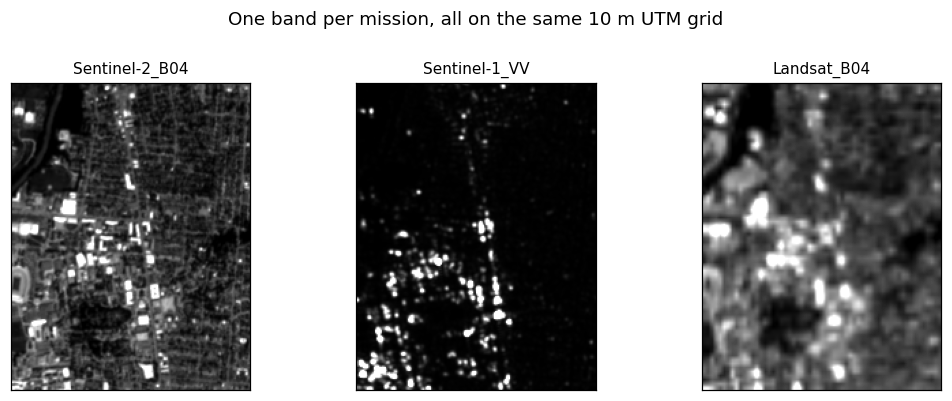

In [25]:
# --- visualise one band per mission to confirm they share the same grid ---
with rasterio.open(fused_path) as src:
    fused_arr   = src.read()
    fused_descs = list(src.descriptions or [])

def find_band(descs, *suffixes):
    '''Find the first band whose name ends with any of *suffixes.'''
    for s in suffixes:
        for i, d in enumerate(descs):
            if d and (d == s or d.endswith("_" + s)):
                return i
    return None

picks = []
for label, suffixes, cm in [
    ("Sentinel-2 B04", ("B04",),       "gray"),
    ("Sentinel-1 VV",  ("VV",),        "gray"),
    ("Landsat B04",    ("B04",),       "gray"),     # may be None if Landsat skipped
    ("DEM",            ("DEM",),       "terrain"),
    ("WorldCover",     ("LULC",),      "tab20"),
]:
    # pick by mission-prefixed name
    target = None
    for i, d in enumerate(fused_descs):
        if d and d.endswith("_" + suffixes[0]):
            mission = d.rsplit("_", 1)[0]
            if label.startswith(mission):
                target = i; break
    if target is not None:
        picks.append((target, fused_descs[target], cm))

ncols = min(len(picks), 5)
nrows = int(np.ceil(len(picks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows + 0.4))
if nrows == 1: axes = np.array([axes])
for ax in axes.flat:
    ax.axis("off")
for i, (bi, name, cm) in enumerate(picks):
    ax = axes.flat[i]
    ax.axis("on")
    band = fused_arr[bi]
    if cm in ("gray",):
        ax.imshow(stretch01(band), cmap=cm)
    else:
        ax.imshow(band, cmap=cm)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("One band per mission, all on the same 10 m UTM grid", y=1.00)
plt.tight_layout(); plt.show()

Every panel above has the **same shape, same CRS, same pixel size**. The
fused TIFF is now ready to be tiled and fed to a multi-modal model, with
each band traceable back to its original mission via its prefix.

The sidecar JSON next to the fused TIFF records the bands list, the
output CRS, the resolution, and the source paths — handy for downstream
provenance tracking.

## 10. Reading metadata back from a tile

Every tile the pipeline writes carries two kinds of provenance information
**embedded as GeoTIFF tags** (no sidecar required):

- **`source_*`** tags — copied from the source scene's `userdata.json`
  (satellite, acquisition date, scene id, provider, collection) and, for
  fused tiles, from the fusion's `.meta.json` sidecar (band list, source
  paths, fusion bbox mode, resolution).
- **`tile_*`** tags — the parameters of *this particular* tile
  (`tile_window_x`, `tile_window_y`, `tile_split_method`,
  `tile_split_assigned`, `tile_nan_handling`, `tile_n_nan_before`,
  `tile_n_filled`, `tile_n_cloud_masked`, `tile_augmentation`, ...).

You read them back with `rasterio.open(tile).tags()`. The band names live
on `src.descriptions`.

In [26]:
# pick the first tile of the 'block' split run on S2
tile_paths = sorted((SPLITS_DIR / "block" / "train").glob("*.tif"))
sample_tile = tile_paths[0]
print(f"Inspecting:  {os.path.relpath(sample_tile, OUT)}\n")

with rasterio.open(sample_tile) as src:
    tags  = src.tags()
    descs = list(src.descriptions or [])
    print(f"shape (C,H,W) : ({src.count}, {src.height}, {src.width})")
    print(f"CRS           : {src.crs}")
    print(f"transform     : {src.transform}")
    print(f"band descriptions:")
    for i, d in enumerate(descs, 1):
        print(f"  band {i}: {d}")

# pretty-print source_* vs tile_* keys
sources = {k: v for k, v in tags.items() if k.startswith("source_")}
tiles   = {k: v for k, v in tags.items() if k.startswith("tile_")}
others  = {k: v for k, v in tags.items() if not (k.startswith("source_") or k.startswith("tile_"))}

print("\nsource_* tags  (where did this tile come from?):")
for k, v in sources.items():
    print(f"  {k:>28s} = {v}")

print("\ntile_* tags  (how was this tile cut?):")
for k, v in tiles.items():
    print(f"  {k:>28s} = {v}")

if others:
    print("\nother tags:")
    for k, v in others.items():
        print(f"  {k:>28s} = {v}")

Inspecting:  tiles/splits/block/train/tile_00000.tif

shape (C,H,W) : (5, 64, 64)
CRS           : EPSG:32617
transform     : | 9.98, 0.00, 327554.54|
| 0.00,-9.99, 4431376.53|
| 0.00, 0.00, 1.00|
band descriptions:
  band 1: B04
  band 2: B08
  band 3: SCL
  band 4: AOT
  band 5: WVP

source_* tags  (where did this tile come from?):
        source_acquisitionDate = 2024-06-12T16:32:20.476000Z
                  source_bands = B04,B08,SCL,AOT,WVP
             source_cloudCover = 0.102747
             source_collection = sentinel-2-l2a
           source_mosaic_tiles = 1
               source_provider = earthsearch
              source_satellite = sentinel-2b
                 source_static = False
                 source_tileId = S2B_17TLE_20240612_0_L2A

tile_* tags  (how was this tile cut?):
             tile_augmentation = none
       tile_cloud_mask_applied = False
      tile_has_valid_mask_band = False
             tile_nan_handling = mask
           tile_n_cloud_masked = 0
          

Useful follow-ups:

- **Group tiles by source scene** — just sort by `source_tileId`.
- **Filter out augmented variants** — `tile_augmentation == "none"`.
- **Reconstruct the original split** — read `tile_split_method` and
  `tile_split_assigned`. No need to keep a separate manifest file.
- **Audit data quality** — `tile_n_nan_before`, `tile_n_filled`,
  `tile_n_cloud_masked` tell you how many pixels were touched.

## 11. Augmentation

Pass `augment=True` to `tile_geotiff` and every tile gains **five
augmented variants**: horizontal flip, vertical flip, 90° rotation,
270° rotation, and additive Gaussian noise. Each variant carries the
same `source_*` tags as the parent (so provenance is preserved) plus its
own `tile_augmentation` tag (`flipH`, `flipV`, `rot90`, `rot270`, `noise`).

In [27]:
AUG_DIR = TILES / "s2_augmented"
if AUG_DIR.exists(): shutil.rmtree(AUG_DIR)

tile_geotiff(
    input_tiff=tiff_s2,
    output_dir=str(AUG_DIR),
    tile_size=TILE_SIZE, stride=TILE_SIZE,
    augment=True, output_mode="geotiff",
    train_val_test_split=(1.0, 0.0, 0.0),
    split_method="random",
    nan_handling="mask",
)

# pick the parent tile of the first set of augmented variants
parents = sorted((AUG_DIR / "train").glob("tile_*.tif"))
parents = [p for p in parents if "_" not in p.stem[len("tile_00000"):]]  # exclude augmented
parent = parents[0]
# the augmented siblings share the parent's tile_id prefix
sibs = sorted((AUG_DIR / "train").glob(f"{parent.stem}_*.tif"))
print(f"Parent tile : {parent.name}")
print(f"Augmented variants ({len(sibs)}):")
for s in sibs:
    print(f"  {s.name}")

🚫 Padding disabled — last partial tiles may be dropped.


  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:00<00:00,  2.51it/s]

100%|██████████| 3/3 [00:00<00:00,  7.06it/s]

✅ Done. Metadata saved → /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs/tiles/s2_augmented/tiles_metadata.csv
🧩 Total tiles created: 6 | split_method='random' | nan_handling='mask'
   train=6  val=0  test=0
Parent tile : tile_00000.tif
Augmented variants (5):
  tile_00000_flipH.tif
  tile_00000_flipV.tif
  tile_00000_noise.tif
  tile_00000_rot270.tif
  tile_00000_rot90.tif


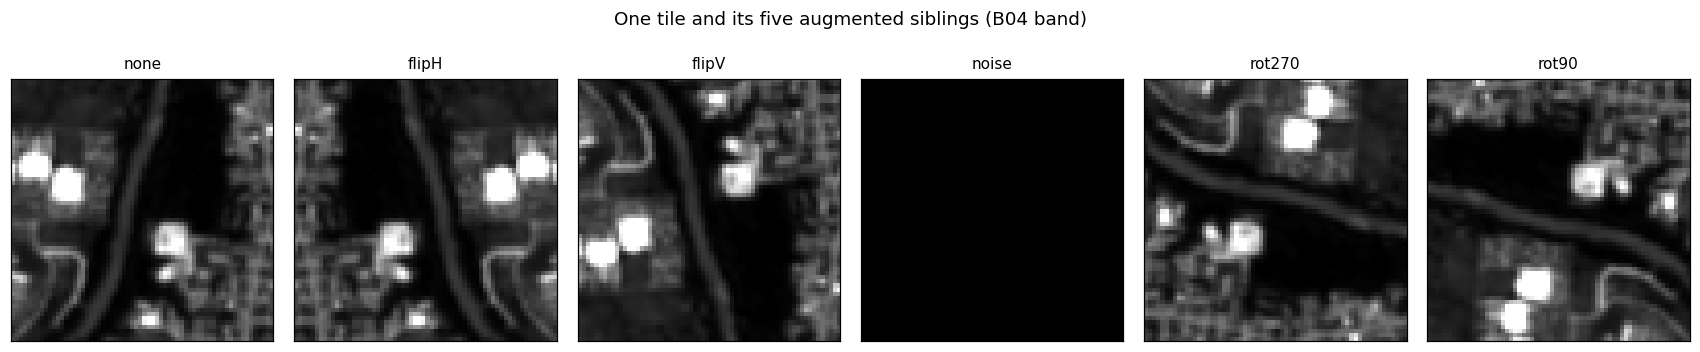


Shared source_* keys between augmented variant and parent: 9
  e.g. source_satellite = sentinel-2b

parent.tile_augmentation     = none
augmented.tile_augmentation  = flipH


In [28]:
# --- show parent + each augmented variant ---
all_tiles = [parent] + sibs
fig, axes = plt.subplots(1, len(all_tiles), figsize=(2.6 * len(all_tiles), 3.0))
for ax, p in zip(axes, all_tiles):
    with rasterio.open(p) as src:
        arr   = src.read()
        descs = list(src.descriptions or [])
        tags  = src.tags()
    bi = descs.index("B04") if "B04" in descs else 0
    ax.imshow(stretch01(arr[bi]), cmap="gray")
    label = tags.get("tile_augmentation", "?")
    ax.set_title(label, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("One tile and its five augmented siblings (B04 band)", y=1.05)
plt.tight_layout(); plt.show()

# confirm provenance is preserved
with rasterio.open(sibs[0]) as src:
    src_tags = src.tags()
with rasterio.open(parent) as src:
    par_tags = src.tags()
shared = {k: v for k, v in src_tags.items() if k.startswith("source_")}
print(f"\nShared source_* keys between augmented variant and parent: {len(shared)}")
print(f"  e.g. source_satellite = {shared.get('source_satellite')}")
print(f"\nparent.tile_augmentation     = {par_tags.get('tile_augmentation')}")
print(f"augmented.tile_augmentation  = {src_tags.get('tile_augmentation')}")

## 12. Exporting for training (Zarr / LMDB)

For real training runs you usually don't want thousands of tiny GeoTIFFs
— I/O overhead dominates. The pipeline ships two export helpers that
roll the tiles into chunked, GPU-friendly stores:

- **`export_zarr.py`** — writes a `tiles.zarr` group with one chunked
  array per split plus a `metadata.json`. Plays nicely with `dask`,
  `xarray`, and the `dataset_loader.py` PyTorch dataset.
- **`export_lmdb.py`** — writes a single LMDB key-value store. Tiny
  random-read latency, ideal for shuffled epoch iteration on a single
  GPU box.

We don't run them here (a real export to Zarr can take a minute or two
and we want this notebook fast); see those scripts for the exact CLI.
The Zarr cube that ships with the repo for the
[`example_datacube_ml.ipynb`](example_datacube_ml.ipynb) notebook was
built with `export_zarr.py`.

## 13. Doing the same thing from plain Python (`python main.py`)

Everything you've seen here can be reproduced from a single command-line
invocation. Open `modules/sentinel_pipeline/main.py`, edit the
`USER INPUT` block at the top to look like:

```python
PROVIDER   = "auto"
MISSION    = "Sentinel-2"
BANDS      = None
AOI        = {"bbox": [-83.020, 39.995, -83.000, 40.015]}   # tiny Columbus
ROI        = resolve_aoi(AOI)
TIME_RANGE = ("2024-06-01", "2024-06-30")
RESOLUTION = 10
MAX_CLOUD  = 0.20
TILE_SIZE  = 64
SPLIT      = (0.8, 0.1, 0.1)
```

Then:

```bash
cd modules/sentinel_pipeline
python main.py
```

`main.py` does the same thing as this notebook's sections 3 (fetch) + 5
(cloud mask) + 6 (NaN handling) + 7-8 (tile + split): it writes
`data/<Mission>_<date>_<scene_id>/response.tiff`, computes NDVI, masks
clouds, tiles into `data/<scene>/tiles_v2/{train,val,test}/`, and saves a
quick-look PNG.

To run several missions in one shot, drive the pipeline from a small bash
loop:

```bash
cd modules/sentinel_pipeline
for M in Sentinel-2 Sentinel-1 Landsat Copernicus-DEM ESA-WorldCover; do
    sed -i.bak "s/^MISSION.*/MISSION = '$M'/" main.py
    python main.py
done
```

The notebook is great for exploration; plain Python is what you want for
production, CI, and batch scheduling.

## 14. Running on an HPC cluster (SLURM)

SLURM is the job scheduler used by most academic HPC clusters. You write
a short shell script that begins with `#SBATCH` directives describing
the resources you need (CPUs, memory, walltime, partition) and ends with
your actual command (`python main.py`). The cluster's scheduler queues
your job, runs it on a compute node when resources are free, and writes
stdout/stderr to log files. Three commands cover 90% of the workflow:
`sbatch script.sbatch` (submit), `squeue -u $USER` (check status),
`scancel <jobid>` (cancel).

Two **generic** templates live in [`slurm_examples/`](../slurm_examples/):

- [`single_fetch.sbatch`](../slurm_examples/single_fetch.sbatch) — one
  job, one mission, one AOI; the cluster equivalent of running
  `python main.py` locally.
- [`array_fetch.sbatch`](../slurm_examples/array_fetch.sbatch) — a SLURM
  **job array** that fetches many (mission, time-range) tuples in
  parallel from a single submission. The tuple table lives in the script
  itself; edit it, update `--array=0-N`, submit once.

Both have placeholder `--account`, `--partition`, and `--mail-user`
values — fill in your cluster's values before submitting. The templates
deliberately do not name any cluster (Unity, OSC, Pitzer, etc.) so they
work anywhere SLURM does.

For cluster-specific guidance (module names, partition lists, JupyterHub
URLs, conda activation patterns, GPU partitions, fairshare) see the
[**BuckAI HPC Handbook**](https://github.com/buckai-observatory/buckai-hpc-handbook).

## 15. Where to go next

You now have:
- A working data cube over Columbus (every mission you fetched, fused
  onto a common UTM grid).
- Tiled, split, optionally cloud-masked and NaN-handled training data.
- Embedded provenance in every tile.

Next steps:

- **Train a model** on the cube. The companion notebook
  [`example_datacube_ml.ipynb`](example_datacube_ml.ipynb) walks through
  a tiny PyTorch U-Net on a bundled Zarr cube; swap in your own cube to
  get started.
- **Scale up.** Pick a bigger AOI (the `center+side_miles` format makes
  this easy), a longer time range, and run on an HPC node using the
  SLURM templates.
- **Add a new mission.** Drop a new entry in
  `modules/sentinel_pipeline/missions.py` describing the STAC collection,
  asset map, default bands, and (optionally) cloud-mask rule. The rest
  of the pipeline picks it up automatically.
- **Report bugs / feature requests** on
  [github.com/buckai-observatory/geoai-datacubes](https://github.com/buckai-observatory/geoai-datacubes).
- **Get in touch** with the BuckAI Observatory at
  [buckai-observatory.org](https://buckai-observatory.org) — we're
  happy to help with new applications, point you at related tools, or
  bring you in as a collaborator.

Happy modelling.